
# Smart-Kage locomotor activity master analysis

This notebook combines the activity-analysis CSV files from all Smart-Kage cohorts into one master dataset.

## Intended cohort structure

- **6m:** cohort 1 + cohort 2
- **12m:** one cohort
- **24m:** cohort 1 + cohort 2
- Final comparison: **WT versus NLGF** across **6m, 12m and 24m**

The notebook:

1. Finds the expected CSV files inside each cohort folder.
2. Adds `Age` and `Cohort` labels.
3. Keeps WT and NLGF only.
4. Prevents mice with the same kage number in different cohorts being treated as the same animal.
5. Combines each outcome into a master table.
6. Produces quality-control summaries.
7. Creates age-by-genotype figures.
8. Runs WT-versus-NLGF tests within each age and age comparisons within each genotype.
9. Exports the combined datasets and statistics.

Edit only the paths in the **cohort configuration** cell before running the notebook.


In [1]:
from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages

MASTER_OUTPUT = Path("/Volumes/Aimi_SmrtKg/SmartKage_activity_master_output")
PDF_OUTPUT_DIR = MASTER_OUTPUT / "figure_pdfs"
PDF_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
_pdf_counter=1
def save_current_pdf():
    global _pdf_counter
    fig=plt.gcf()
    if fig is None or not fig.get_axes():
        return
    title=""
    if getattr(fig,"_suptitle",None) is not None:
        title=fig._suptitle.get_text()
    if not title and fig.axes:
        title=fig.axes[0].get_title()
    if not title:
        title=f"Figure_{_pdf_counter}"
    safe="".join(ch if ch.isalnum() or ch in "._-" else "_" for ch in title)
    fig.savefig(PDF_OUTPUT_DIR/f"{_pdf_counter:02d}_{safe}.pdf",bbox_inches="tight",format="pdf")
    print("Saved PDF",_pdf_counter)
    _pdf_counter+=1


In [2]:

# ==========================================================
# IMPORTS AND GLOBAL SETTINGS
# ==========================================================

from pathlib import Path
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore", category=FutureWarning)

AGE_ORDER = ["6m", "12m", "24m"]
GENO_ORDER = ["WT", "NLGF"]

GENO_COLORS = {
    "WT": "#2EC4C7",
    "NLGF": "#F05AA6",
}

PERIOD_ORDER = [
    "9pm-3am",
    "3am-9am",
    "9am-3pm",
    "3pm-9pm",
]

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 400,
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 22,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "legend.title_fontsize": 16,
    "axes.spines.top": False,
    "axes.spines.right": False,
})



## 1. Cohort configuration

Replace each placeholder path with the folder containing that cohort's exported CSV files.

The notebook searches recursively, so the CSV files can be inside a subfolder such as `report_output`, `movement_analysis`, or `figures`.


In [3]:

# ==========================================================
# EDIT THESE PATHS
# ==========================================================

COHORTS = [
    {
        "cohort": "6m_cohort1",
        "age": "6m",
        "root": Path(r"/Volumes/Aimi_SmrtKg/2024-05-may-jul_NLGF6m"),
    },
    {
        "cohort": "6m_cohort2",
        "age": "6m",
        "root": Path(r"/Volumes/Aimi_SmrtKg/2026-01-Jan-Mar_NLGF6m_Coh2"),
    },
    {
        "cohort": "12m_cohort1",
        "age": "12m",
        "root": Path(r"/Volumes/Aimi_SmrtKg/2024-07-jul-sep_NLGF12m"),
    },
    {
        "cohort": "24m_cohort1",
        "age": "24m",
        "root": Path(r"/Volumes/Aimi_SmrtKg/2025-04-Apr-May_NLGF24m_Coh1"),
    },
    {
        "cohort": "24m_cohort2",
        "age": "24m",
        "root": Path(r"/Volumes/Aimi_SmrtKg/2025-05-May-June_NLGF24m-Coh2"),
    },
]

MASTER_OUTPUT = Path.cwd() / "/Volumes/Aimi_SmrtKg/SmartKage_activity_master_output"
MASTER_OUTPUT.mkdir(parents=True, exist_ok=True)

print("Outputs will be saved to:")
print(MASTER_OUTPUT)


Outputs will be saved to:
/Volumes/Aimi_SmrtKg/SmartKage_activity_master_output


## 2. Expected files and outcome definitions

In [4]:

# ==========================================================
# EXPECTED FILES
# ==========================================================

FILE_SPECS = {
    "average_daily_locomotion": {
        "filename": "Average_daily_locomotion_duration_Figure15.csv",
        "kind": "mouse_summary",
        "value_col": "duration (min)",
        "ylabel": "Average daily locomotion duration (min)",
    },
    "locomotion_by_period": {
        "filename": "Locomotion_Analysis_Figure16.csv",
        "kind": "mouse_period",
        "value_col": "duration (min)",
        "ylabel": "Locomotion duration (min)",
    },
    "locomotion_bout_number": {
        "filename": "Locomotion_Fragmentation_Analysis_Bout_Number_Figure17.csv",
        "kind": "mouse_period",
        "value_col": "N bouts",
        "ylabel": "Number of locomotion bouts",
    },
    "locomotion_bout_duration": {
        "filename": "Locomotion_Fragmentation_Analysis_Bout_Duration_Figure18.csv",
        "kind": "mouse_period",
        "value_col": "duration (min)",
        "ylabel": "Mean locomotion bout duration (min)",
    },
    "average_daily_quiescence": {
        "filename": "Average_daily_quiescence_duration_Figure19.csv",
        "kind": "mouse_summary",
        "value_col": "duration (min)",
        "ylabel": "Average daily quiescence duration (min)",
    },
    "quiescence_by_period": {
        "filename": "Quiescence_Analysis_Figure20.csv",
        "kind": "mouse_period",
        "value_col": "duration (min)",
        "ylabel": "Quiescence duration (min)",
    },
    "quiescence_bout_number": {
        "filename": "Quiescence_Fragmentation_Analysis_Bout_Number_Figure21.csv",
        "kind": "mouse_period",
        "value_col": "N bouts",
        "ylabel": "Number of quiescence bouts",
    },
    "quiescence_bout_duration": {
        "filename": "Quiescence_Fragmentation_Analysis_Bout_Duration_Figure22.csv",
        "kind": "mouse_period",
        "value_col": "duration (min)",
        "ylabel": "Mean quiescence bout duration (min)",
    },
}


## 3. Loading and standardisation functions

In [5]:

# ==========================================================
# LOADING HELPERS
# ==========================================================


def _normalise_filename(name):
    """
    Normalise file names so small differences do not stop matching.

    Examples treated as equivalent:
      Locomotion_Analysis_Figure16.csv
      locomotion analysis figure16.csv
      Locomotion-Analysis-Figure16 (1).csv
    """
    name = Path(str(name)).name.lower()
    name = re.sub(r"\(\d+\)(?=\.csv$)", "", name)
    return re.sub(r"[^a-z0-9]+", "", name)


def resolve_cohort_root(configured_root):
    """
    Resolve the configured cohort folder.

    If the exact path does not exist, search recursively from the mounted
    drive for a directory with the same cohort-folder name. This helps when
    cohorts are stored at different folder depths.
    """
    configured_root = Path(configured_root).expanduser()

    if configured_root.exists():
        return configured_root

    target_name = configured_root.name.lower()

    # Use the mounted-volume root when possible.
    parts = configured_root.parts
    if len(parts) >= 3 and parts[1] == "Volumes":
        search_base = Path("/") / parts[1] / parts[2]
    else:
        search_base = configured_root.parent

    if not search_base.exists():
        raise FileNotFoundError(
            f"Configured cohort folder does not exist:\n{configured_root}\n"
            f"The fallback search base also does not exist:\n{search_base}"
        )

    print(
        f"Configured cohort path was not found:\n  {configured_root}\n"
        f"Searching all folders below:\n  {search_base}"
    )

    matches = []
    for current_root, dirnames, _ in os.walk(search_base, followlinks=True):
        for dirname in dirnames:
            if dirname.lower() == target_name:
                matches.append(Path(current_root) / dirname)

    if not matches:
        raise FileNotFoundError(
            f"Could not locate a folder named {configured_root.name!r} "
            f"anywhere below:\n{search_base}"
        )

    matches = sorted(matches, key=lambda p: (len(p.parts), str(p).lower()))

    if len(matches) > 1:
        print("Multiple cohort folders matched:")
        for match in matches:
            print("  ", match)
        print("Using:", matches[0])

    return matches[0]


def find_unique_file(root, filename):
    """
    Search through every subfolder for the requested CSV.

    Matching is:
      - recursive through all directory levels;
      - case-insensitive;
      - insensitive to spaces, underscores and hyphens;
      - tolerant of duplicate suffixes such as '(1)'.

    Exact-name matches are preferred over normalised-name matches.
    """
    root = resolve_cohort_root(root)
    target_normalised = _normalise_filename(filename)

    exact_matches = []
    normalised_matches = []
    searched_csv_count = 0

    # os.walk is used explicitly so every nested folder is visited,
    # including cohorts with a different internal organisation.
    for current_root, _, files in os.walk(root, followlinks=True):
        for file_name in files:
            if not file_name.lower().endswith(".csv"):
                continue

            searched_csv_count += 1
            candidate = Path(current_root) / file_name

            if file_name.lower() == filename.lower():
                exact_matches.append(candidate)
            elif _normalise_filename(file_name) == target_normalised:
                normalised_matches.append(candidate)

    matches = exact_matches if exact_matches else normalised_matches

    if not matches:
        # Show similarly named CSVs to make debugging easier.
        keywords = {
            token for token in re.findall(r"[a-z0-9]+", filename.lower())
            if len(token) >= 4 and token not in {"figure", "analysis"}
        }

        similar = []
        for current_root, _, files in os.walk(root, followlinks=True):
            for file_name in files:
                if not file_name.lower().endswith(".csv"):
                    continue
                lower_name = file_name.lower()
                score = sum(keyword in lower_name for keyword in keywords)
                if score:
                    similar.append((score, Path(current_root) / file_name))

        similar = [
            path for _, path in sorted(
                similar,
                key=lambda item: (-item[0], str(item[1]).lower())
            )[:15]
        ]

        message = (
            f"Could not find {filename!r} after checking "
            f"{searched_csv_count} CSV files in every folder below:\n{root}"
        )

        if similar:
            message += "\n\nPossibly related CSV files found:"
            for path in similar:
                message += f"\n  {path}"

        raise FileNotFoundError(message)

    matches = sorted(matches, key=lambda p: (len(p.parts), str(p).lower()))

    if len(matches) > 1:
        print(f"WARNING: multiple copies of {filename} found in {root}")
        for match in matches:
            print("  ", match)
        print("Using the shortest/first path:", matches[0])

    print(f"    Found in: {matches[0].parent}")
    return matches[0]

def clean_genotype(value):
    """Standardise genotype labels."""
    text = str(value).strip()

    mapping = {
        "WT": "WT",
        "wildtype": "WT",
        "Wildtype": "WT",
        "NLGF": "NLGF",
        "AppNL-G-F": "NLGF",
        "APPNL-G-F": "NLGF",
        "NL-G-F": "NLGF",
    }

    return mapping.get(text, text)


def standardise_mouse_level_table(df, cohort_name, age):
    """Standardise mouse-level and mouse-by-period exports."""
    result = df.copy()

    rename_map = {}
    if "group" in result.columns:
        rename_map["group"] = "Genotype"
    if "kage" in result.columns:
        rename_map["kage"] = "KageID"

    result = result.rename(columns=rename_map)

    required = {"KageID", "Genotype"}
    missing = required - set(result.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    result["Genotype"] = result["Genotype"].map(clean_genotype)
    result["KageID"] = result["KageID"].astype(str).str.strip()
    result["Cohort"] = cohort_name
    result["Age"] = age

    # Unique across cohorts, even when kage numbers repeat.
    result["MouseID"] = (
        result["Cohort"].astype(str)
        + "_"
        + result["KageID"].astype(str)
    )

    # Final requested analysis includes WT and NLGF only.
    result = result[result["Genotype"].isin(GENO_ORDER)].copy()

    result["Age"] = pd.Categorical(
        result["Age"],
        categories=AGE_ORDER,
        ordered=True,
    )
    result["Genotype"] = pd.Categorical(
        result["Genotype"],
        categories=GENO_ORDER,
        ordered=True,
    )

    if "period" in result.columns:
        result["period"] = pd.Categorical(
            result["period"],
            categories=PERIOD_ORDER,
            ordered=True,
        )

    return result


def standardise_group_summary(df, cohort_name, age):
    """
    Standardise Figure 13b.

    This file contains group means and SEM rather than mouse-level values.
    The group labels are inferred from column position:
      group1 = WT
      group2 = NLGF
      group3 = any third genotype and is excluded.
    """
    result_parts = []

    group_map = {
        1: "WT",
        2: "NLGF",
    }

    for group_number, genotype in group_map.items():
        mean_col = f"mean_group{group_number}"
        sem_col = f"sem_group{group_number}"

        if mean_col not in df.columns:
            continue

        part = pd.DataFrame({
            "hour": pd.to_numeric(df["hour"], errors="coerce"),
            "mean": pd.to_numeric(df[mean_col], errors="coerce"),
            "sem": pd.to_numeric(df.get(sem_col), errors="coerce"),
            "Genotype": genotype,
            "Cohort": cohort_name,
            "Age": age,
        })

        result_parts.append(part)

    if not result_parts:
        return pd.DataFrame()

    result = pd.concat(result_parts, ignore_index=True)
    result["Age"] = pd.Categorical(result["Age"], AGE_ORDER, ordered=True)
    result["Genotype"] = pd.Categorical(
        result["Genotype"], GENO_ORDER, ordered=True
    )

    return result


def load_all_cohorts(cohort_config, file_specs):
    """Load every requested file from every cohort."""
    combined = {name: [] for name in file_specs}
    loading_log = []
    LOADED_FILE_CACHE = {}

    for cohort in cohort_config:
        cohort_name = cohort["cohort"]
        age = cohort["age"]
        root = Path(cohort["root"])

        print(f"\nLoading {cohort_name} ({age})")
        print(root)

        for outcome_name, spec in file_specs.items():
            try:
                csv_path = find_unique_file(root, spec["filename"])
                csv_key = str(csv_path.resolve())
                if csv_key in LOADED_FILE_CACHE:
                    raw = LOADED_FILE_CACHE[csv_key].copy()
                    print(f'  ↺ Using cached file: {csv_path.name}')
                else:
                    print(f'  ✓ Loading: {csv_path.name}')
                    raw = pd.read_csv(csv_path)
                    LOADED_FILE_CACHE[csv_key] = raw.copy()

                if spec["kind"] == "group_summary":
                    tidy = standardise_group_summary(raw, cohort_name, age)
                else:
                    tidy = standardise_mouse_level_table(
                        raw,
                        cohort_name,
                        age,
                    )

                tidy["SourceFile"] = str(csv_path)
                combined[outcome_name].append(tidy)

                loading_log.append({
                    "Cohort": cohort_name,
                    "Age": age,
                    "Outcome": outcome_name,
                    "Status": "loaded",
                    "Rows": len(tidy),
                    "Path": str(csv_path),
                })

                print(f"    Ready ({len(tidy)} rows)")

            except Exception as exc:
                loading_log.append({
                    "Cohort": cohort_name,
                    "Age": age,
                    "Outcome": outcome_name,
                    "Status": "failed",
                    "Rows": 0,
                    "Path": "",
                    "Error": str(exc),
                })

                print(f"  ✗ {spec['filename']}")
                print(f"    {exc}")

    master_tables = {}

    for outcome_name, parts in combined.items():
        if parts:
            master_tables[outcome_name] = pd.concat(
                parts,
                ignore_index=True,
            )
        else:
            master_tables[outcome_name] = pd.DataFrame()

    return master_tables, pd.DataFrame(loading_log)


## 4. Load and combine all cohorts

In [6]:

# ==========================================================
# CHECK RESOLVED COHORT FOLDERS BEFORE LOADING
# ==========================================================

resolved_cohort_rows = []

for cohort in COHORTS:
    try:
        resolved_root = resolve_cohort_root(cohort["root"])
        n_csv = sum(
            1
            for current_root, _, files in os.walk(
                resolved_root,
                followlinks=True,
            )
            for file_name in files
            if file_name.lower().endswith(".csv")
        )

        resolved_cohort_rows.append({
            "Cohort": cohort["cohort"],
            "Age": cohort["age"],
            "ConfiguredRoot": str(cohort["root"]),
            "ResolvedRoot": str(resolved_root),
            "CSV_files_found_recursively": n_csv,
            "Status": "ready",
        })

    except Exception as exc:
        resolved_cohort_rows.append({
            "Cohort": cohort["cohort"],
            "Age": cohort["age"],
            "ConfiguredRoot": str(cohort["root"]),
            "ResolvedRoot": "",
            "CSV_files_found_recursively": 0,
            "Status": str(exc),
        })

resolved_cohort_check = pd.DataFrame(resolved_cohort_rows)
display(resolved_cohort_check)


,Cohort,Age,ConfiguredRoot,ResolvedRoot,CSV_files_found_recursively,Status
0,6m_cohort1,6m,/Volumes/Aimi_SmrtKg/2024-05-may-jul_NLGF6m,/Volumes/Aimi_SmrtKg/2024-05-may-jul_NLGF6m,6457,ready
1,6m_cohort2,6m,/Volumes/Aimi_SmrtKg/2026-01-Jan-Mar_NLGF6m_Coh2,/Volumes/Aimi_SmrtKg/2026-01-Jan-Mar_NLGF6m_Coh2,15317,ready
2,12m_cohort1,12m,/Volumes/Aimi_SmrtKg/2024-07-jul-sep_NLGF12m,/Volumes/Aimi_SmrtKg/2024-07-jul-sep_NLGF12m,4441,ready
3,24m_cohort1,24m,/Volumes/Aimi_SmrtKg/2025-04-Apr-May_NLGF24m_Coh1,/Volumes/Aimi_SmrtKg/2025-04-Apr-May_NLGF24m_Coh1,400,ready
4,24m_cohort2,24m,/Volumes/Aimi_SmrtKg/2025-05-May-June_NLGF24m-...,/Volumes/Aimi_SmrtKg/2025-05-May-June_NLGF24m-...,10088,ready


In [7]:

MASTER_TABLES, loading_log = load_all_cohorts(
    COHORTS,
    FILE_SPECS,
)

display(loading_log)

failed_files = loading_log[
    loading_log["Status"].eq("failed")
]

if not failed_files.empty:
    print("\nSome files were not loaded. Check the paths above.")
else:
    print("\nAll expected files were loaded successfully.")


print("\n========== Loaded files ==========")
loaded = loading_log[loading_log["Status"]=="loaded"][["Cohort","Outcome","Path"]].drop_duplicates()
for _, r in loaded.iterrows():
    print(f"{r['Cohort']:<12} | {r['Outcome']:<35} | {Path(r['Path']).name}")
print(f"\nUnique files loaded: {loaded['Path'].nunique()}")



Loading 6m_cohort1 (6m)
/Volumes/Aimi_SmrtKg/2024-05-may-jul_NLGF6m
    Found in: /Volumes/Aimi_SmrtKg/2024-05-may-jul_NLGF6m/report_output_allKages_NOR/report_output
  ✓ Loading: Average_daily_locomotion_duration_Figure15.csv
    Ready (23 rows)
    Found in: /Volumes/Aimi_SmrtKg/2024-05-may-jul_NLGF6m/report_output_allKages_NOR/report_output
  ✓ Loading: Locomotion_Analysis_Figure16.csv
    Ready (92 rows)
    Found in: /Volumes/Aimi_SmrtKg/2024-05-may-jul_NLGF6m/report_output_allKages_NOR/report_output
  ✓ Loading: Locomotion_Fragmentation_Analysis_Bout_Number_Figure17.csv
    Ready (92 rows)
    Found in: /Volumes/Aimi_SmrtKg/2024-05-may-jul_NLGF6m/report_output_allKages_NOR/report_output
  ✓ Loading: Locomotion_Fragmentation_Analysis_Bout_Duration_Figure18.csv
    Ready (92 rows)
    Found in: /Volumes/Aimi_SmrtKg/2024-05-may-jul_NLGF6m/report_output_allKages_NOR/report_output
  ✓ Loading: Average_daily_quiescence_duration_Figure19.csv
    Ready (23 rows)
    Found in: /Volumes/A

,Cohort,Age,Outcome,Status,Rows,Path
0,6m_cohort1,6m,average_daily_locomotion,loaded,23,/Volumes/Aimi_SmrtKg/2024-05-may-jul_NLGF6m/re...
1,6m_cohort1,6m,locomotion_by_period,loaded,92,/Volumes/Aimi_SmrtKg/2024-05-may-jul_NLGF6m/re...
2,6m_cohort1,6m,locomotion_bout_number,loaded,92,/Volumes/Aimi_SmrtKg/2024-05-may-jul_NLGF6m/re...
3,6m_cohort1,6m,locomotion_bout_duration,loaded,92,/Volumes/Aimi_SmrtKg/2024-05-may-jul_NLGF6m/re...
4,6m_cohort1,6m,average_daily_quiescence,loaded,23,/Volumes/Aimi_SmrtKg/2024-05-may-jul_NLGF6m/re...
5,6m_cohort1,6m,quiescence_by_period,loaded,92,/Volumes/Aimi_SmrtKg/2024-05-may-jul_NLGF6m/re...
6,6m_cohort1,6m,quiescence_bout_number,loaded,92,/Volumes/Aimi_SmrtKg/2024-05-may-jul_NLGF6m/re...
7,6m_cohort1,6m,quiescence_bout_duration,loaded,92,/Volumes/Aimi_SmrtKg/2024-05-may-jul_NLGF6m/re...
8,6m_cohort2,6m,average_daily_locomotion,loaded,12,/Volumes/Aimi_SmrtKg/2026-01-Jan-Mar_NLGF6m_Co...
9,6m_cohort2,6m,locomotion_by_period,loaded,48,/Volumes/Aimi_SmrtKg/2026-01-Jan-Mar_NLGF6m_Co...



All expected files were loaded successfully.

========== Loaded files ==========
6m_cohort1   | average_daily_locomotion            | Average_daily_locomotion_duration_Figure15.csv
6m_cohort1   | locomotion_by_period                | Locomotion_Analysis_Figure16.csv
6m_cohort1   | locomotion_bout_number              | Locomotion_Fragmentation_Analysis_Bout_Number_Figure17.csv
6m_cohort1   | locomotion_bout_duration            | Locomotion_Fragmentation_Analysis_Bout_Duration_Figure18.csv
6m_cohort1   | average_daily_quiescence            | Average_daily_quiescence_duration_Figure19.csv
6m_cohort1   | quiescence_by_period                | Quiescence_Analysis_Figure20.csv
6m_cohort1   | quiescence_bout_number              | Quiescence_Fragmentation_Analysis_Bout_Number_Figure21.csv
6m_cohort1   | quiescence_bout_duration            | Quiescence_Fragmentation_Analysis_Bout_Duration_Figure22.csv
6m_cohort2   | average_daily_locomotion            | Average_daily_locomotion_duration_Figure1

## 5. Quality control

In [8]:

# ==========================================================
# QUALITY CONTROL
# ==========================================================

qc_rows = []

for outcome_name, table in MASTER_TABLES.items():

    if table.empty:
        continue

    if "MouseID" not in table.columns:
        # Figure 13b is already group-level, so no mouse counts are possible.
        continue

    counts = (
        table
        .groupby(
            ["Age", "Cohort", "Genotype"],
            observed=True,      # <-- change this
        )
        .agg(
            n_mice=("MouseID", "nunique"),
            n_rows=("MouseID", "size"),
        )
        .reset_index()
    )
    
    counts["Outcome"] = outcome_name
    qc_rows.append(counts)

mouse_counts_qc = pd.concat(qc_rows, ignore_index=True)

display(mouse_counts_qc)

# Detect accidental duplicate mouse-period rows.
duplicate_checks = []

for outcome_name, table in MASTER_TABLES.items():

    if table.empty or "MouseID" not in table.columns:
        continue

    keys = ["MouseID"]

    if "period" in table.columns:
        keys.append("period")

    duplicates = table.duplicated(keys, keep=False)

    duplicate_checks.append({
        "Outcome": outcome_name,
        "Duplicate_rows": int(duplicates.sum()),
    })

duplicate_checks = pd.DataFrame(duplicate_checks)
display(duplicate_checks)


,Age,Cohort,Genotype,n_mice,n_rows,Outcome
0,6m,6m_cohort1,WT,15,15,average_daily_locomotion
1,6m,6m_cohort1,NLGF,8,8,average_daily_locomotion
2,6m,6m_cohort2,WT,5,5,average_daily_locomotion
3,6m,6m_cohort2,NLGF,7,7,average_daily_locomotion
4,12m,12m_cohort1,WT,10,10,average_daily_locomotion
...,...,...,...,...,...,...
75,12m,12m_cohort1,NLGF,12,48,quiescence_bout_duration
76,24m,24m_cohort1,WT,16,64,quiescence_bout_duration
77,24m,24m_cohort1,NLGF,6,24,quiescence_bout_duration
78,24m,24m_cohort2,WT,4,16,quiescence_bout_duration


,Outcome,Duplicate_rows
0,average_daily_locomotion,0
1,locomotion_by_period,0
2,locomotion_bout_number,0
3,locomotion_bout_duration,0
4,average_daily_quiescence,0
5,quiescence_by_period,0
6,quiescence_bout_number,0
7,quiescence_bout_duration,0



## 6. Plotting functions

The summary outcomes are shown as age × genotype plots.

For period-based outcomes, the four six-hour periods are shown separately.


In [9]:

# ==========================================================
# PLOTTING HELPERS
# ==========================================================

def sem(values):
    values = pd.to_numeric(pd.Series(values), errors="coerce").dropna()
    if len(values) < 2:
        return np.nan
    return stats.sem(values)


def plot_mouse_summary(table, value_col, ylabel, title):
    """Age-by-genotype summary with individual mice."""
    data = table.copy()
    data[value_col] = pd.to_numeric(data[value_col], errors="coerce")

    summary = (
        data
        .groupby(
            ["Age", "Genotype"],
            observed=False,
            as_index=False,
        )
        .agg(
            mean=(value_col, "mean"),
            sem=(value_col, sem),
            n=("MouseID", "nunique"),
        )
    )

    fig, ax = plt.subplots(figsize=(8, 6))

    x_positions = np.arange(len(AGE_ORDER))
    width = 0.34

    for geno_index, genotype in enumerate(GENO_ORDER):
        geno_summary = summary[
            summary["Genotype"].eq(genotype)
        ].set_index("Age").reindex(AGE_ORDER)

        offset = (
            -width / 2
            if geno_index == 0
            else width / 2
        )

        ax.bar(
            x_positions + offset,
            geno_summary["mean"],
            width=width,
            yerr=geno_summary["sem"],
            capsize=4,
            alpha=0.55,
            color=GENO_COLORS[genotype],
            label=genotype,
            edgecolor="black",
            linewidth=0.7,
        )

        for age_index, age in enumerate(AGE_ORDER):
            values = data.loc[
                data["Age"].eq(age)
                & data["Genotype"].eq(genotype),
                value_col,
            ].dropna()

            jitter = np.linspace(-0.06, 0.06, max(len(values), 1))

            ax.scatter(
                np.full(len(values), x_positions[age_index] + offset)
                + jitter[:len(values)],
                values,
                s=35,
                alpha=0.75,
                color=GENO_COLORS[genotype],
                edgecolor="white",
                linewidth=0.5,
                zorder=3,
            )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(AGE_ORDER)
    ax.set_xlabel("Age")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(frameon=False, title="Genotype")

    plt.tight_layout()
    save_current_pdf()
    plt.show()

    return summary


def plot_period_outcome(table, value_col, ylabel, title):
    """Thesis-ready period figure with RAW WT-vs-NLGF significance stars."""
    data = table.copy()
    data[value_col] = pd.to_numeric(data[value_col], errors="coerce")

    fig, axes = plt.subplots(1, len(AGE_ORDER), figsize=(22, 7.5), sharey=False)
    axes = np.atleast_1d(axes)
    x_positions = np.arange(len(PERIOD_ORDER))
    width = 0.34

    def raw_p(vals1, vals2):
        a = pd.to_numeric(pd.Series(vals1),errors="coerce").dropna()
        b = pd.to_numeric(pd.Series(vals2),errors="coerce").dropna()
        if len(a)<2 or len(b)<2: return np.nan
        pa = stats.shapiro(a).pvalue if len(a)>=3 else 0
        pb = stats.shapiro(b).pvalue if len(b)>=3 else 0
        if pa>0.05 and pb>0.05:
            return stats.ttest_ind(a,b,equal_var=False,nan_policy="omit").pvalue
        return stats.mannwhitneyu(a,b,alternative="two-sided").pvalue

    def stars(p):
        if pd.isna(p) or p>=0.05: return ""
        if p<0.0001:return "****"
        if p<0.001:return "***"
        if p<0.01:return "**"
        return "*"

    for ax, age in zip(axes, AGE_ORDER):
        age_data = data[data["Age"].eq(age)].copy()
        panel_max = pd.to_numeric(age_data[value_col],errors="coerce").max()
        panel_min = pd.to_numeric(age_data[value_col],errors="coerce").min()
        span = max(panel_max-panel_min, abs(panel_max)*0.2, 1)

        for gi, genotype in enumerate(GENO_ORDER):
            offset = -width/2 if gi==0 else width/2
            means, errors = [], []
            for period in PERIOD_ORDER:
                vals = age_data.loc[
                    age_data["Genotype"].eq(genotype)&age_data["period"].eq(period),
                    value_col].dropna()
                means.append(vals.mean()); errors.append(sem(vals))
            ax.bar(x_positions+offset, means, width=width, yerr=errors,
                   capsize=5, alpha=0.55, color=GENO_COLORS[genotype],
                   label=genotype, edgecolor="black", linewidth=0.8)
            for pi, period in enumerate(PERIOD_ORDER):
                vals = age_data.loc[
                    age_data["Genotype"].eq(genotype)&age_data["period"].eq(period),
                    value_col].dropna()
                jitter=np.linspace(-0.055,0.055,max(len(vals),1))
                ax.scatter(np.full(len(vals),x_positions[pi]+offset)+jitter[:len(vals)],
                           vals,s=38,alpha=0.7,color=GENO_COLORS[genotype],
                           edgecolor="white",linewidth=0.5,zorder=3)

        # raw significance stars WT vs NLGF for each period
        for pi, period in enumerate(PERIOD_ORDER):
            wt=age_data.loc[age_data["Genotype"].eq("WT")&age_data["period"].eq(period),value_col]
            ng=age_data.loc[age_data["Genotype"].eq("NLGF")&age_data["period"].eq(period),value_col]
            p=raw_p(wt,ng); st=stars(p)
            if st:
                local = pd.to_numeric(age_data.loc[age_data["period"].eq(period),value_col],errors="coerce").max()
                y = local + 0.10*span
                h = 0.035*span
                ax.plot([pi-width/2,pi-width/2,pi+width/2,pi+width/2],
                        [y,y+h,y+h,y],color="black",lw=1.5,clip_on=False)
                ax.text(pi,y+h,st,ha="center",va="bottom",
                        fontsize=18,fontweight="bold",clip_on=False)
        ax.set_ylim(ax.get_ylim()[0], max(ax.get_ylim()[1], panel_max+0.28*span))
        ax.set_title(age)
        ax.set_xticks(x_positions)
        ax.set_xticklabels(PERIOD_ORDER, rotation=30, ha="right")
        ax.set_xlabel("Period")
        ax.set_ylabel(ylabel if age==AGE_ORDER[0] else "")

    handles,labels=axes[-1].get_legend_handles_labels()
    fig.legend(handles[:2],labels[:2],frameon=False,title="Genotype",loc="upper right")
    fig.suptitle(title,y=1.02)
    plt.tight_layout(rect=[0,0,0.95,1])
    save_current_pdf()
    plt.show()


## 7. Generate all combined figures

Saved PDF 1


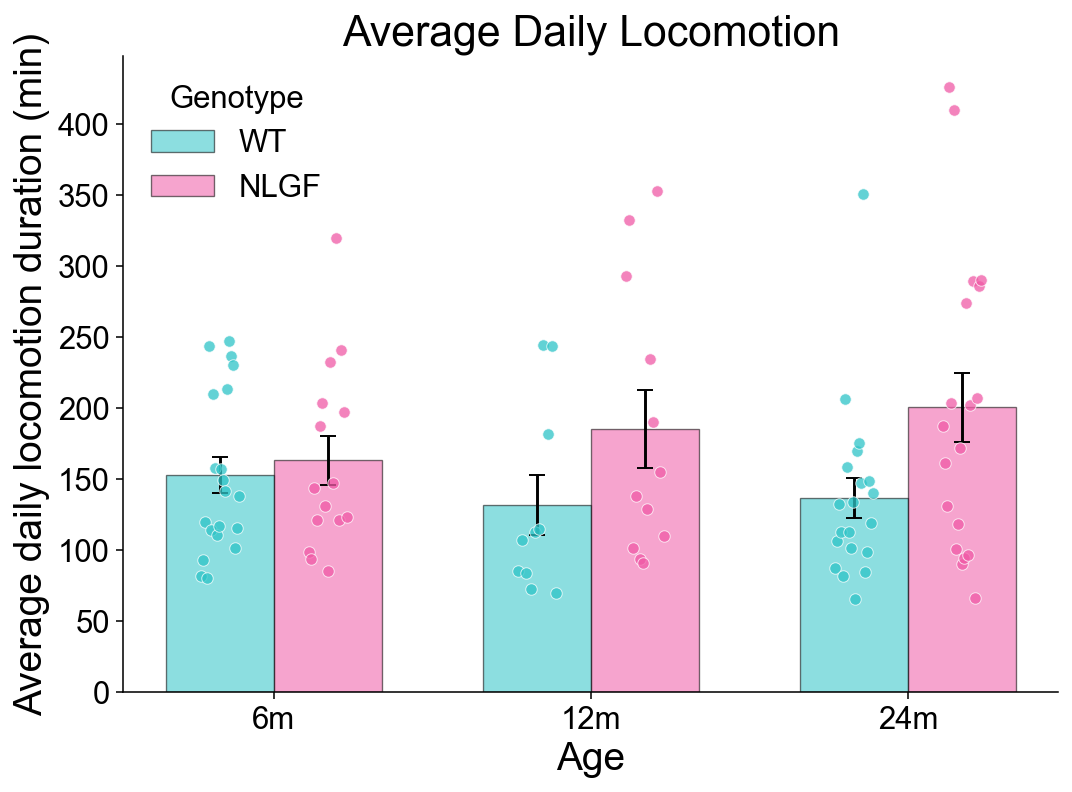

Saved PDF 2


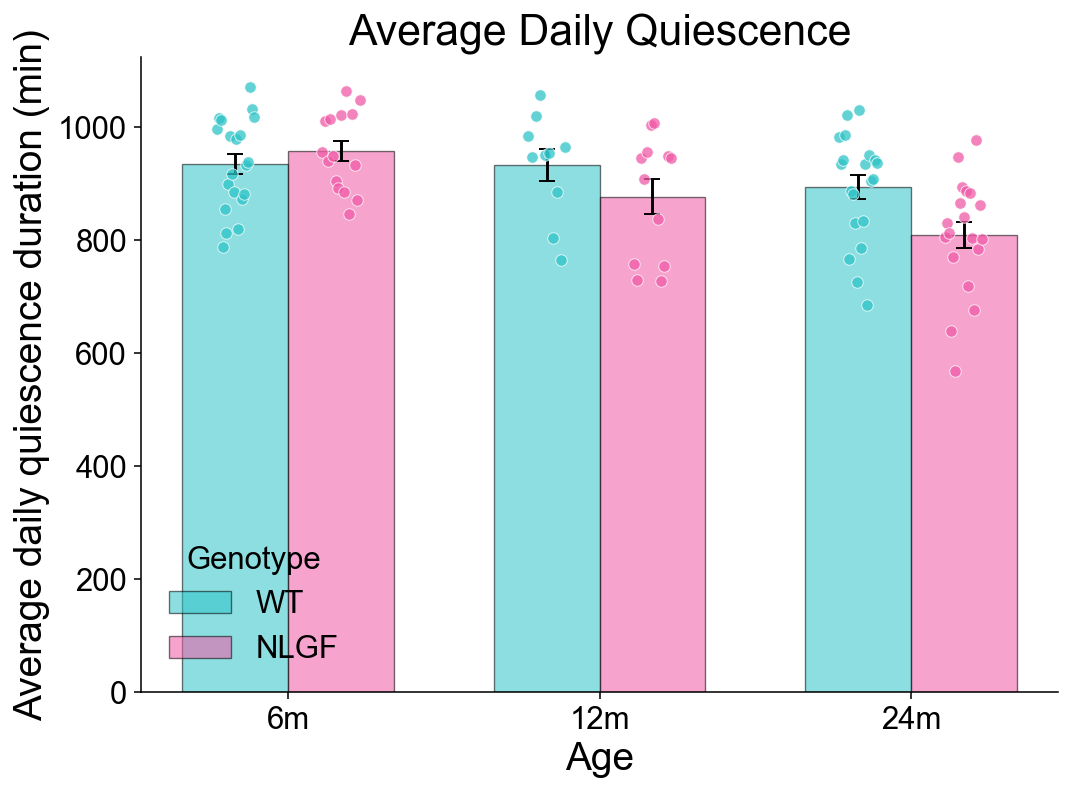

Saved: /Volumes/Aimi_SmrtKg/SmartKage_activity_master_output/average_locomotion.pdf


In [10]:

# ==========================================================
# SUMMARY OUTCOME FIGURES
# ==========================================================

summary_outcomes = [
    "average_daily_locomotion",
    "average_daily_quiescence",
]

SUMMARY_TABLES = {}

for outcome_name in summary_outcomes:
    table = MASTER_TABLES[outcome_name]

    if table.empty:
        print(f"Skipping {outcome_name}: no data")
        continue

    spec = FILE_SPECS[outcome_name]

    SUMMARY_TABLES[outcome_name] = plot_mouse_summary(
        table=table,
        value_col=spec["value_col"],
        ylabel=spec["ylabel"],
        title=outcome_name.replace("_", " ").title(),
    )

# Save the figure that plot_mouse_summary() just created

print(f"Saved: {MASTER_OUTPUT / 'average_locomotion.pdf'}")

Saved PDF 3


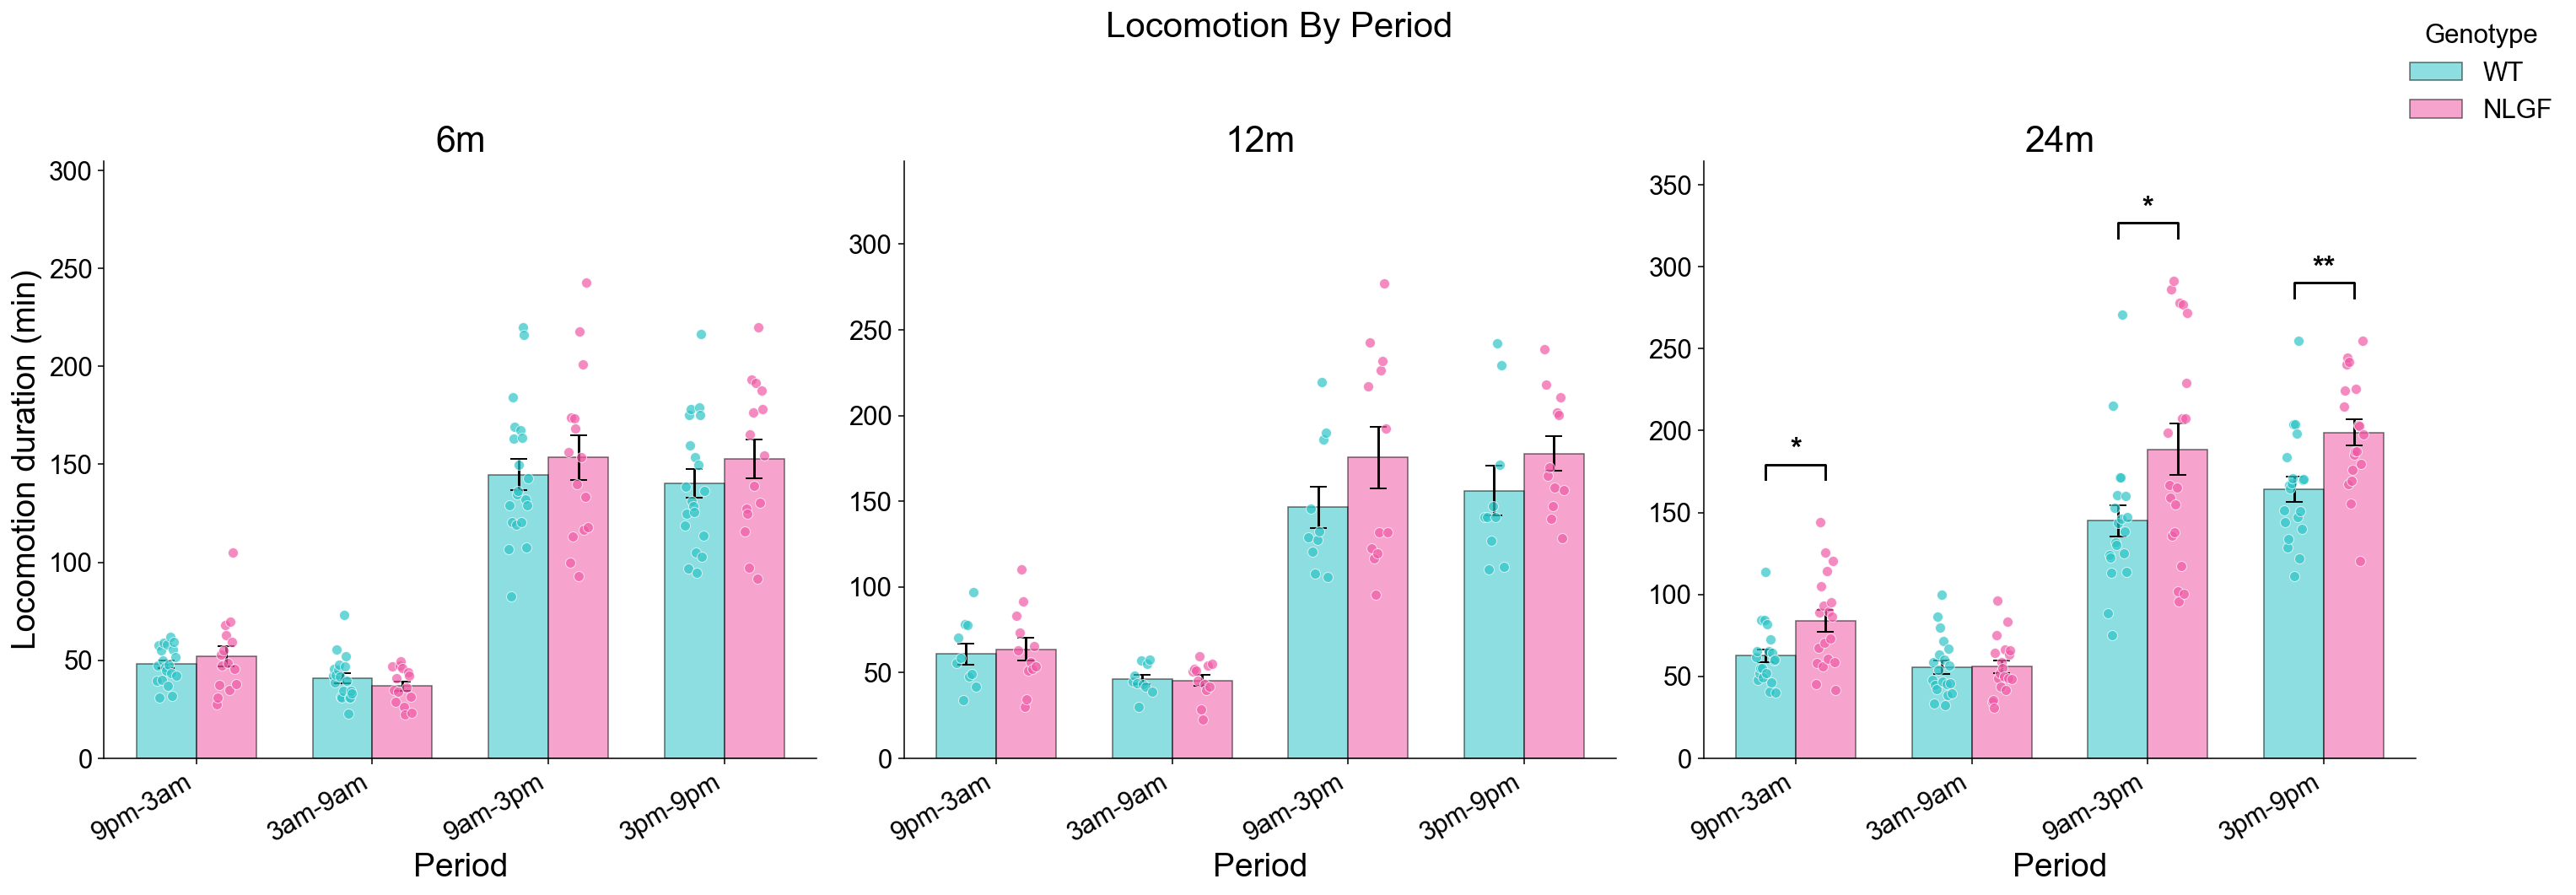

Saved PDF 4


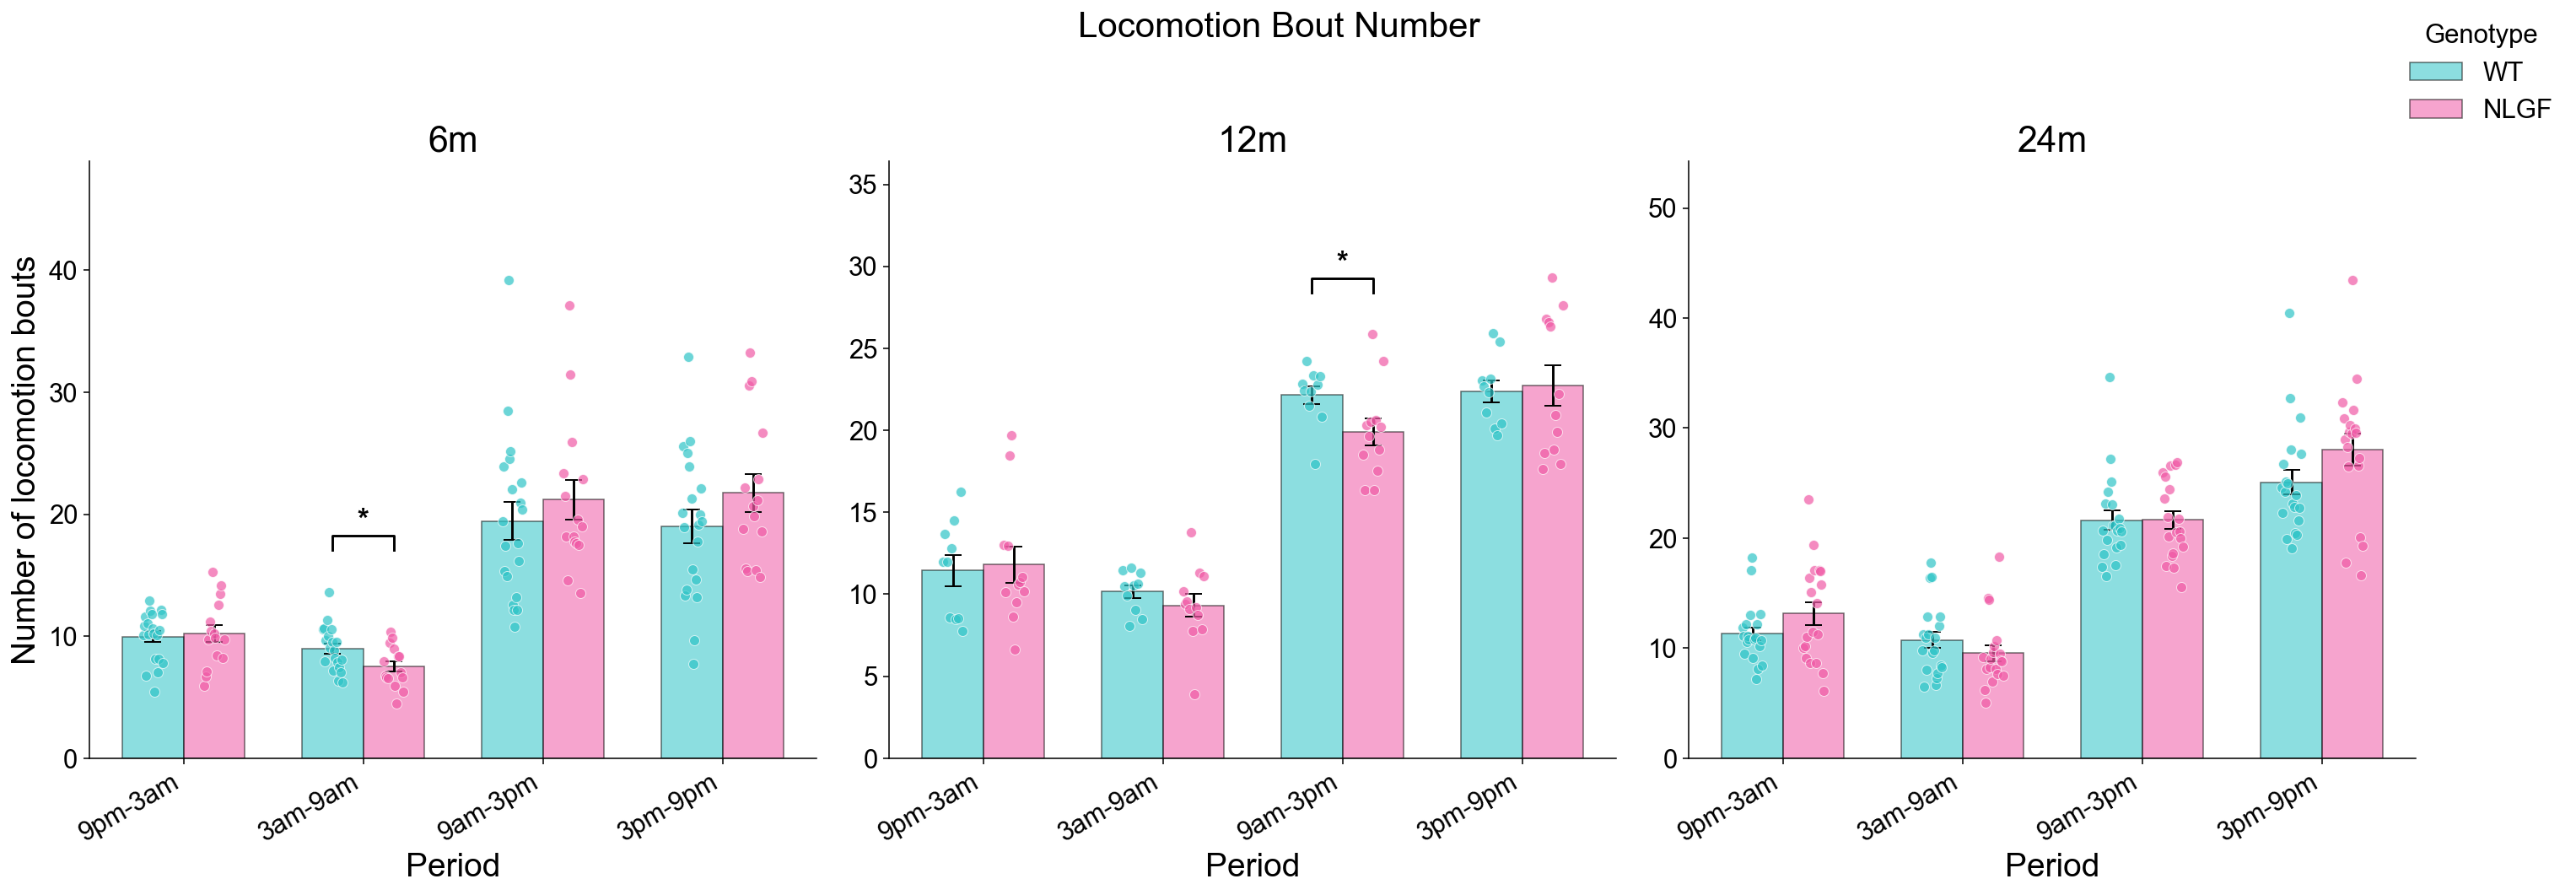

Saved PDF 5


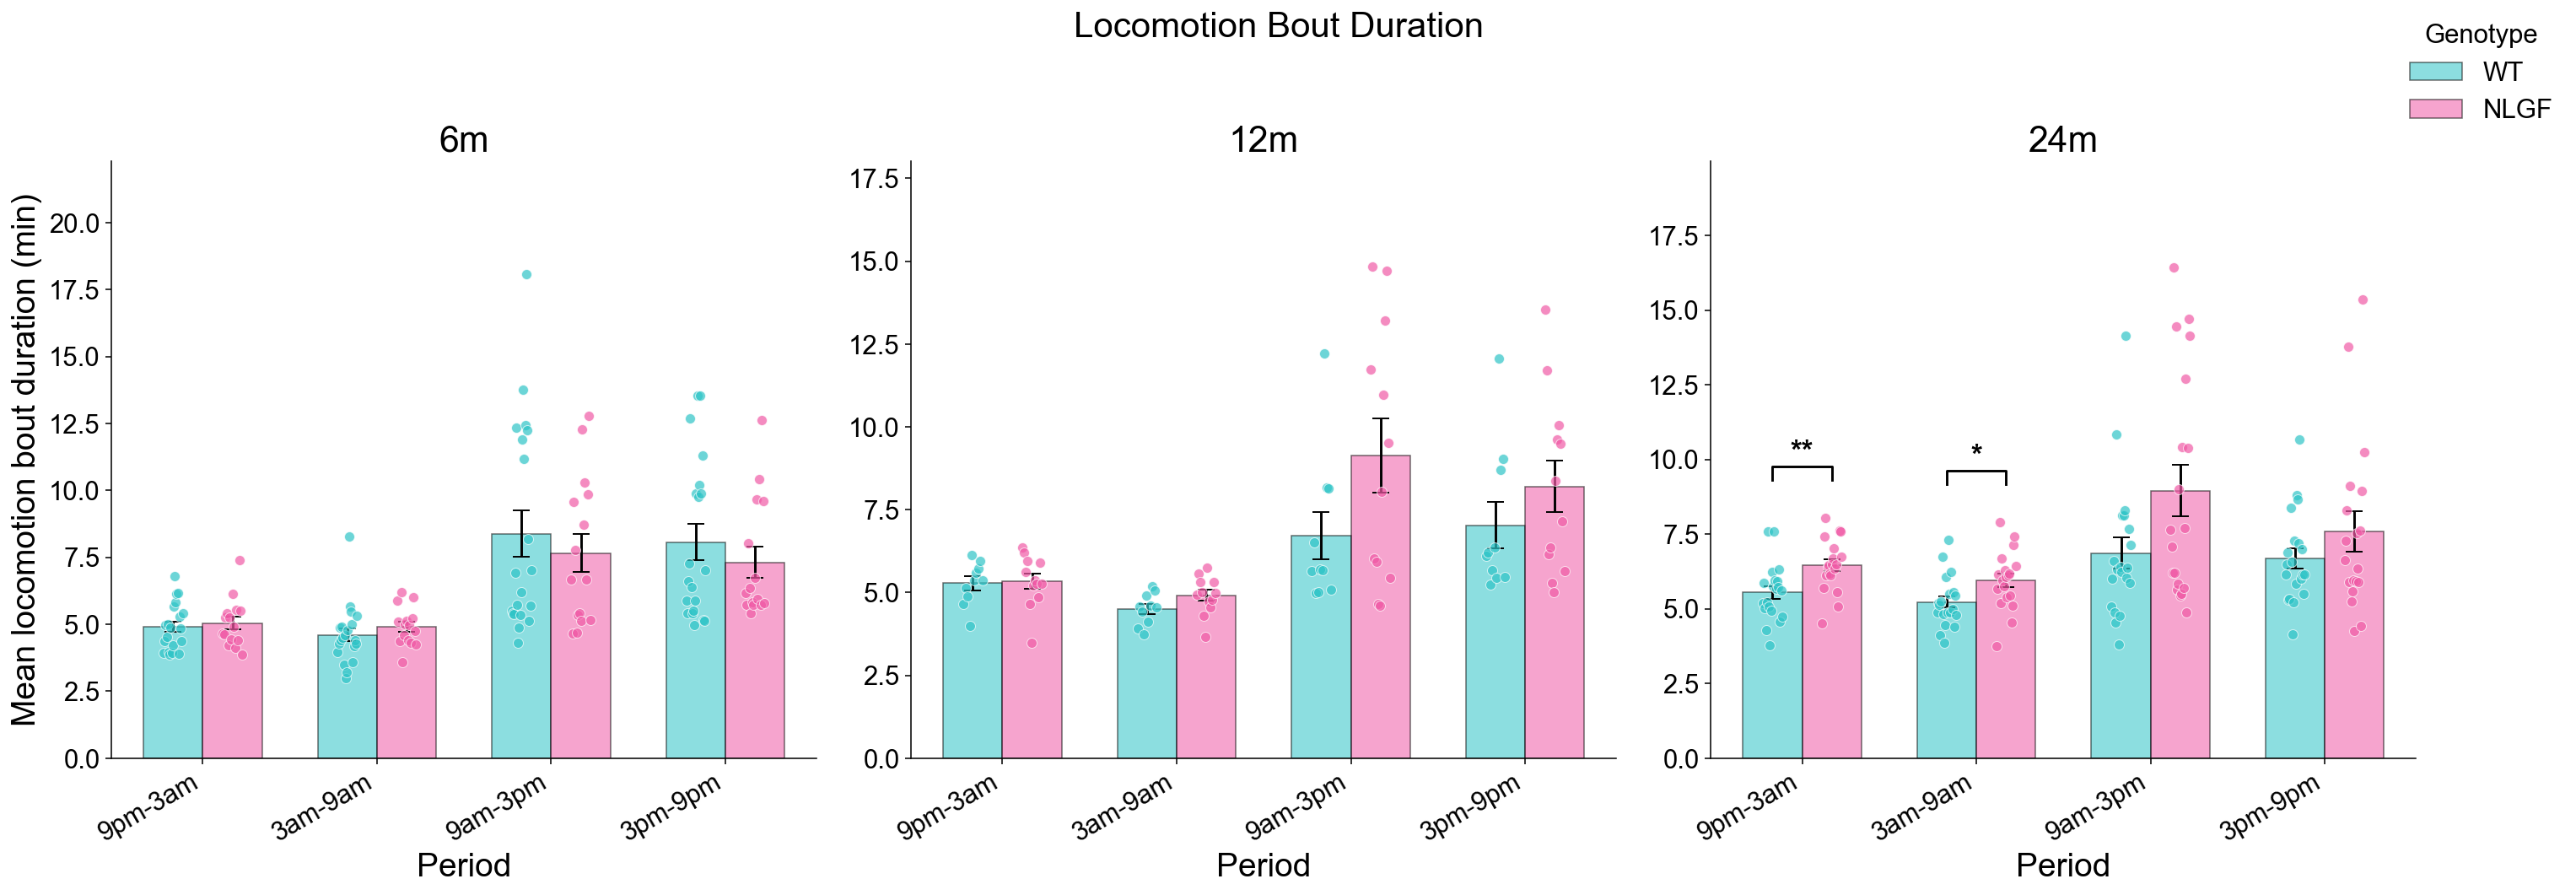

Saved PDF 6


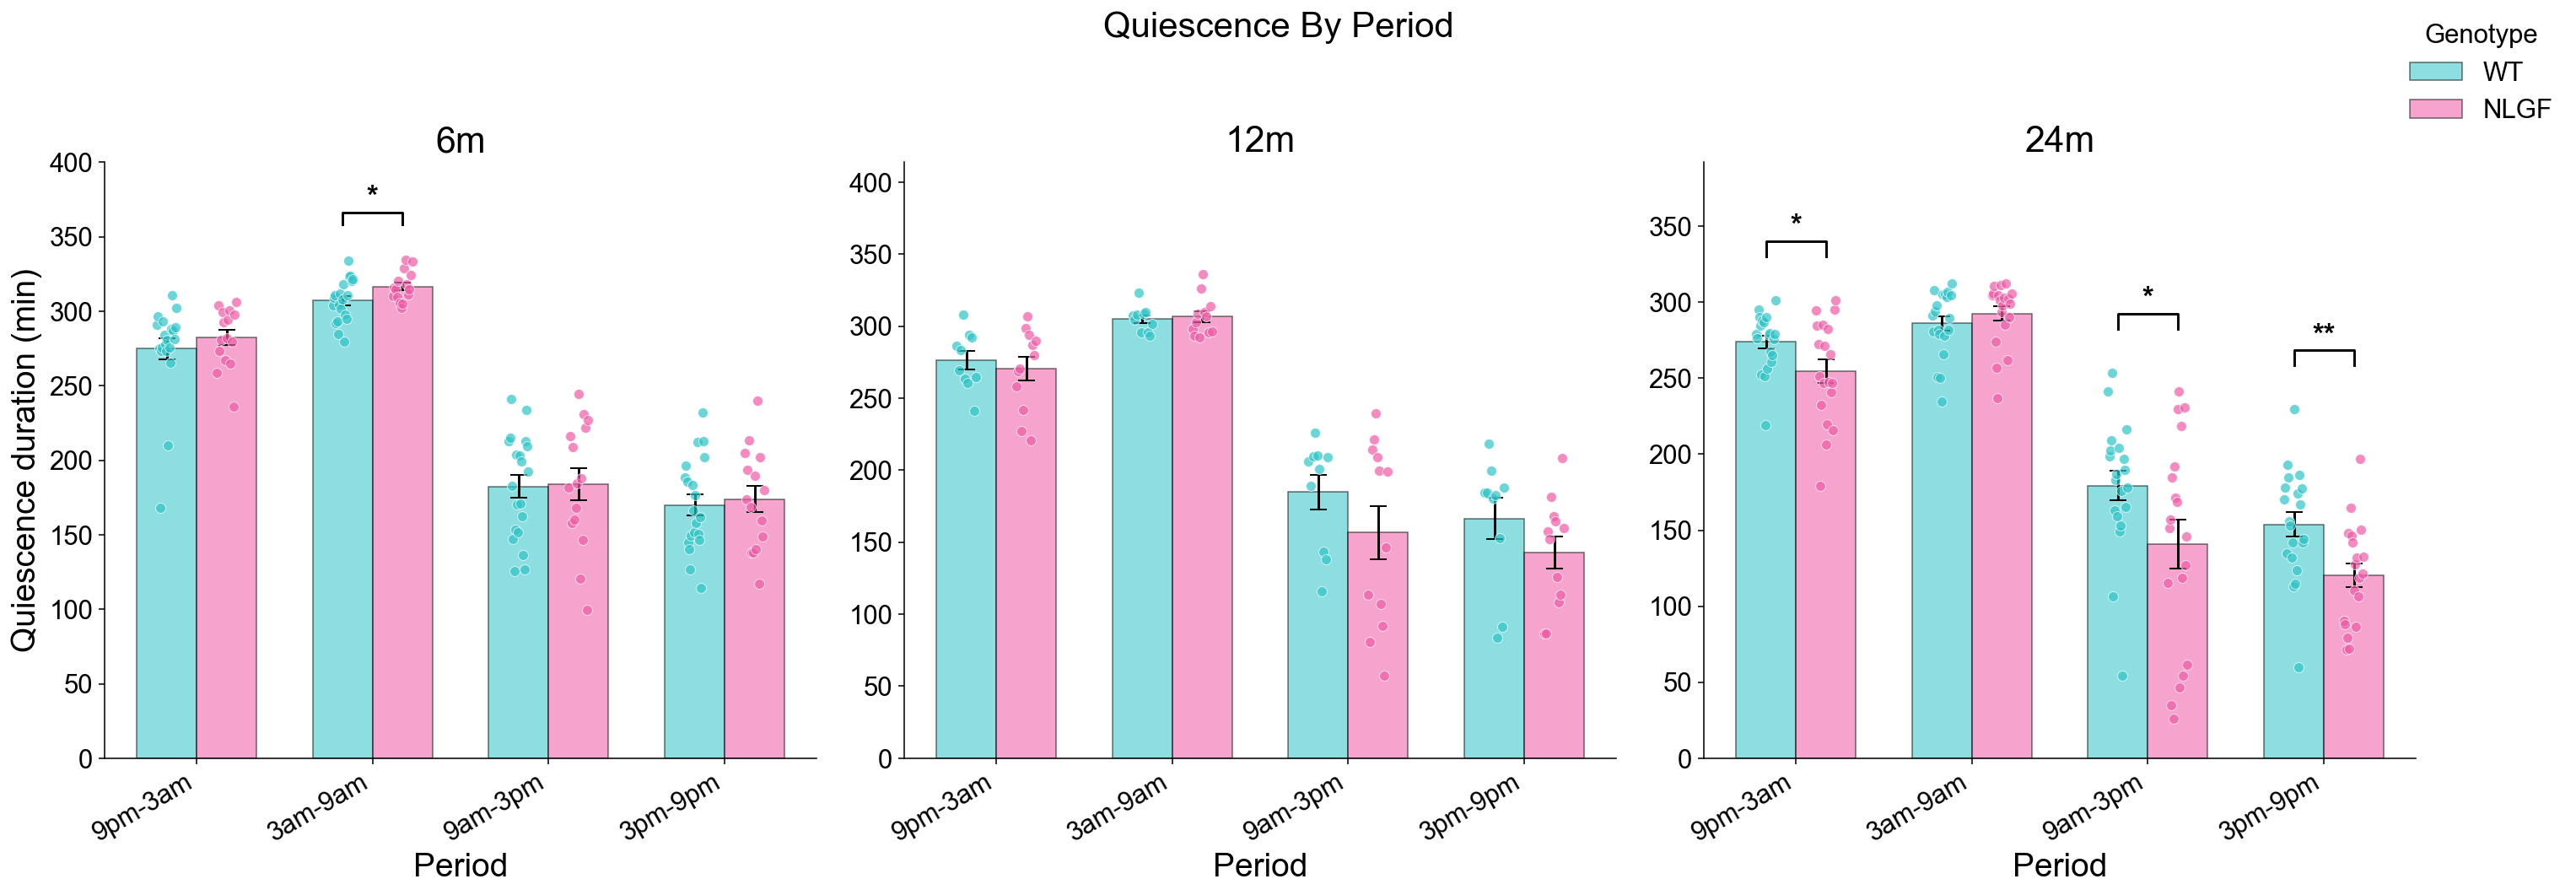

Saved PDF 7


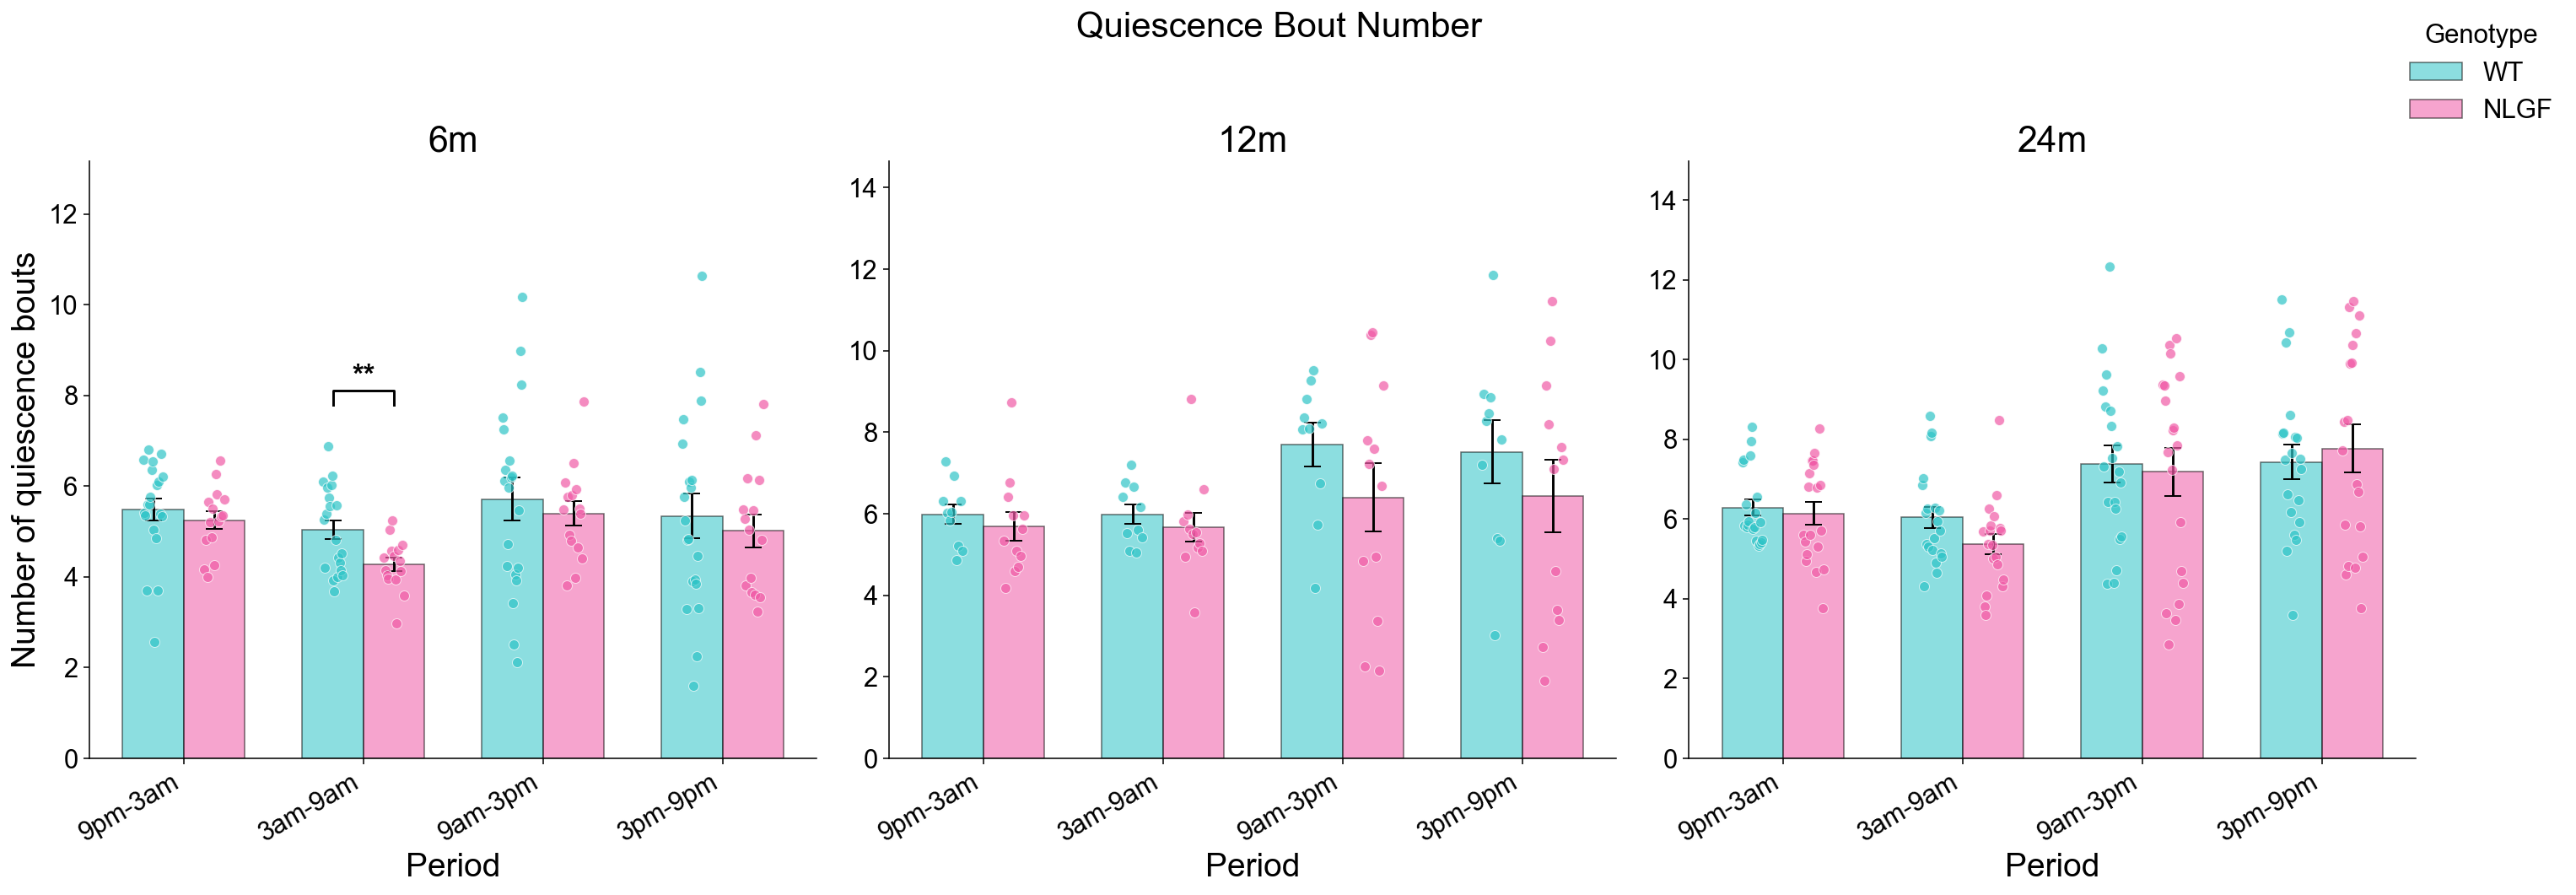

Saved PDF 8


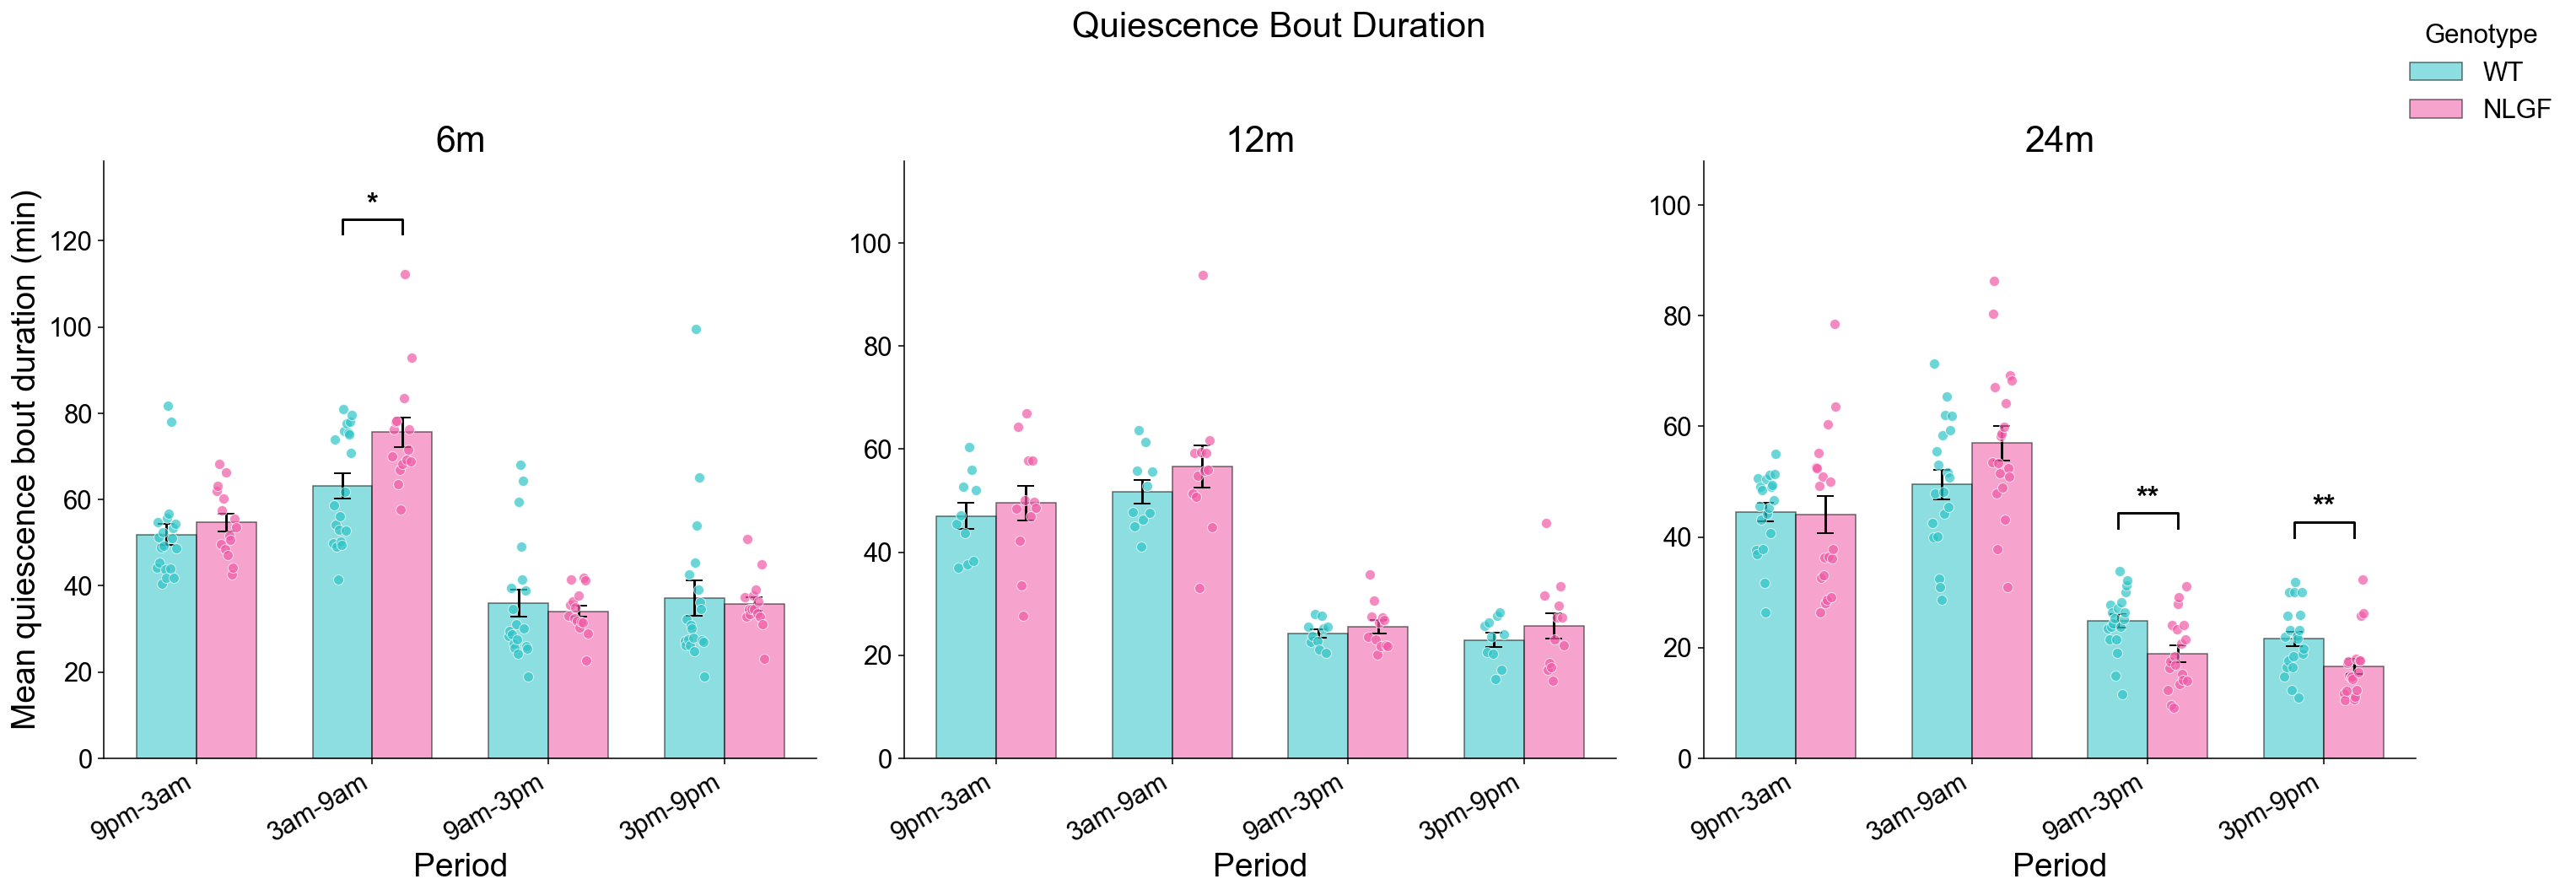

In [11]:

# ==========================================================
# PERIOD-BASED OUTCOME FIGURES
# ==========================================================

period_outcomes = [
    "locomotion_by_period",
    "locomotion_bout_number",
    "locomotion_bout_duration",
    "quiescence_by_period",
    "quiescence_bout_number",
    "quiescence_bout_duration",
]

for outcome_name in period_outcomes:
    table = MASTER_TABLES[outcome_name]

    if table.empty:
        print(f"Skipping {outcome_name}: no data")
        continue

    spec = FILE_SPECS[outcome_name]

    plot_period_outcome(
        table=table,
        value_col=spec["value_col"],
        ylabel=spec["ylabel"],
        title=outcome_name.replace("_", " ").title(),
    )



## 8. Average daily movement profile

`Figure13b` contains group means and SEM rather than individual mouse values.  
The notebook therefore combines cohort-level curves by averaging cohort means. It does **not** use this file for mouse-level inferential statistics.


In [12]:
# Figure 13b (Average_Daily_Movement_Duration) intentionally omitted.
# The 12m cohort does not contain this file, so it is excluded from the
# master analysis to keep all cohorts consistent.
print("Skipping Average_Daily_Movement_Duration_Figure13b (not available for all cohorts).")


Skipping Average_Daily_Movement_Duration_Figure13b (not available for all cohorts).



## 9. Statistical comparisons

For each mouse-level outcome:

- **WT versus NLGF within each age:** Welch's independent-samples t-test when both groups are approximately normal; otherwise Mann–Whitney U.
- **Age comparisons within each genotype:** Welch one-way ANOVA where possible, followed by pairwise Welch t-tests; otherwise Kruskal–Wallis followed by pairwise Mann–Whitney tests.
- Holm correction is applied to the pairwise comparisons.

For period-based outcomes, the same comparisons are run separately within each six-hour period.

These tests treat cohorts as pooled biological replicates after checking cohort-specific sample sizes. Cohort remains available in every master table for later mixed-effects modelling if required.


In [13]:

# ==========================================================
# STATISTICAL HELPERS
# ==========================================================

def clean_values(values):
    values = pd.Series(values)
    values = pd.to_numeric(
        values,
        errors="coerce"
    )
    return values.dropna().to_numpy(dtype=float)


def shapiro_safe(values):
    values = clean_values(values)

    if len(values) < 3:
        return np.nan

    if len(values) > 5000:
        values = values[:5000]

    try:
        return stats.shapiro(values).pvalue
    except Exception:
        return np.nan


def compare_two_groups(group_a, group_b):
    a = clean_values(group_a)
    b = clean_values(group_b)

    result = {
        "n_a": len(a),
        "n_b": len(b),
        "mean_a": np.mean(a) if len(a) else np.nan,
        "mean_b": np.mean(b) if len(b) else np.nan,
        "shapiro_a_p": shapiro_safe(a),
        "shapiro_b_p": shapiro_safe(b),
        "test": None,
        "statistic": np.nan,
        "p_raw": np.nan,
    }

    if len(a) < 2 or len(b) < 2:
        result["test"] = "insufficient data"
        return result

    normal_a = (
        np.isnan(result["shapiro_a_p"])
        or result["shapiro_a_p"] >= 0.05
    )
    normal_b = (
        np.isnan(result["shapiro_b_p"])
        or result["shapiro_b_p"] >= 0.05
    )

    if normal_a and normal_b:
        test_result = stats.ttest_ind(
            a,
            b,
            equal_var=False,
            nan_policy="omit",
        )
        result["test"] = "Welch t-test"
    else:
        test_result = stats.mannwhitneyu(
            a,
            b,
            alternative="two-sided",
        )
        result["test"] = "Mann–Whitney U"

    result["statistic"] = test_result.statistic
    result["p_raw"] = test_result.pvalue

    return result


def add_holm_correction(results, family_columns):
    corrected_parts = []

    for _, family in results.groupby(
        family_columns,
        dropna=False,
        sort=False,
    ):
        family = family.copy()
        valid = family["p_raw"].notna()

        family["p_holm"] = np.nan

        if valid.any():
            family.loc[valid, "p_holm"] = multipletests(
                family.loc[valid, "p_raw"],
                method="holm",
            )[1]

        family["stars"] = family["p_holm"].map(
            lambda p: (
                "****" if pd.notna(p) and p < 0.0001
                else "***" if pd.notna(p) and p < 0.001
                else "**" if pd.notna(p) and p < 0.01
                else "*" if pd.notna(p) and p < 0.05
                else "ns"
            )
        )

        corrected_parts.append(family)

    return pd.concat(corrected_parts, ignore_index=True)


def run_genotype_tests(table, value_col, outcome_name):
    rows = []

    period_values = (
        PERIOD_ORDER
        if "period" in table.columns
        else [None]
    )

    for period in period_values:
        period_data = (
            table[table["period"].eq(period)]
            if period is not None
            else table
        )

        for age in AGE_ORDER:
            age_data = period_data[
                period_data["Age"].eq(age)
            ]

            result = compare_two_groups(
                age_data.loc[
                    age_data["Genotype"].eq("WT"),
                    value_col,
                ],
                age_data.loc[
                    age_data["Genotype"].eq("NLGF"),
                    value_col,
                ],
            )

            result.update({
                "Outcome": outcome_name,
                "Comparison": "WT vs NLGF",
                "Age": age,
                "Period": period,
                "Group_A": "WT",
                "Group_B": "NLGF",
            })

            rows.append(result)

    results = pd.DataFrame(rows)

    correction_family = ["Outcome"]
    if "Period" in results.columns:
        correction_family.append("Period")

    return add_holm_correction(
        results,
        family_columns=correction_family,
    )


def run_age_pairwise_tests(table, value_col, outcome_name):
    rows = []

    age_pairs = [
        ("6m", "12m"),
        ("6m", "24m"),
        ("12m", "24m"),
    ]

    period_values = (
        PERIOD_ORDER
        if "period" in table.columns
        else [None]
    )

    for period in period_values:
        period_data = (
            table[table["period"].eq(period)]
            if period is not None
            else table
        )

        for genotype in GENO_ORDER:
            genotype_data = period_data[
                period_data["Genotype"].eq(genotype)
            ]

            for age_a, age_b in age_pairs:
                result = compare_two_groups(
                    genotype_data.loc[
                        genotype_data["Age"].eq(age_a),
                        value_col,
                    ],
                    genotype_data.loc[
                        genotype_data["Age"].eq(age_b),
                        value_col,
                    ],
                )

                result.update({
                    "Outcome": outcome_name,
                    "Comparison": "Age comparison",
                    "Genotype": genotype,
                    "Period": period,
                    "Group_A": age_a,
                    "Group_B": age_b,
                })

                rows.append(result)

    results = pd.DataFrame(rows)

    correction_family = ["Outcome", "Genotype"]
    if "Period" in results.columns:
        correction_family.append("Period")

    return add_holm_correction(
        results,
        family_columns=correction_family,
    )


In [14]:

# ==========================================================
# RUN STATISTICS FOR ALL MOUSE-LEVEL OUTCOMES
# ==========================================================

GENOTYPE_STATS = []
AGE_STATS = []

for outcome_name, spec in FILE_SPECS.items():
    table = MASTER_TABLES[outcome_name]

    if (
        table.empty
        or spec["kind"] == "group_summary"
        or spec["value_col"] is None
    ):
        continue

    value_col = spec["value_col"]

    genotype_results = run_genotype_tests(
        table,
        value_col=value_col,
        outcome_name=outcome_name,
    )

    age_results = run_age_pairwise_tests(
        table,
        value_col=value_col,
        outcome_name=outcome_name,
    )

    GENOTYPE_STATS.append(genotype_results)
    AGE_STATS.append(age_results)

GENOTYPE_STATS = pd.concat(
    GENOTYPE_STATS,
    ignore_index=True,
)

AGE_STATS = pd.concat(
    AGE_STATS,
    ignore_index=True,
)

print("WT versus NLGF tests")
display(GENOTYPE_STATS)

print("Age comparisons within genotype")
display(AGE_STATS)


WT versus NLGF tests


,n_a,n_b,mean_a,mean_b,shapiro_a_p,shapiro_b_p,test,statistic,p_raw,Outcome,Comparison,Age,Period,Group_A,Group_B,p_holm,stars
0,20,15,152.79035,162.998733,0.027767,0.141617,Mann–Whitney U,137.000000,0.676922,average_daily_locomotion,WT vs NLGF,6m,None,WT,NLGF,0.676922,ns
1,10,12,131.43230,185.001083,0.017475,0.051739,Mann–Whitney U,36.000000,0.121251,average_daily_locomotion,WT vs NLGF,12m,None,WT,NLGF,0.242502,ns
2,20,19,136.50535,200.376947,0.000617,0.083591,Mann–Whitney U,121.000000,0.054269,average_daily_locomotion,WT vs NLGF,24m,None,WT,NLGF,0.162807,ns
3,20,15,47.96470,52.099467,0.463077,0.105252,Welch t-test,-0.756087,0.458995,locomotion_by_period,WT vs NLGF,6m,9pm-3am,WT,NLGF,0.917989,ns
4,10,12,60.92220,63.588167,0.803796,0.808471,Welch t-test,-0.294145,0.771680,locomotion_by_period,WT vs NLGF,12m,9pm-3am,WT,NLGF,0.917989,ns
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,10,12,24.25230,25.515917,0.665118,0.209957,Welch t-test,-0.828927,0.418035,quiescence_bout_duration,WT vs NLGF,12m,9am-3pm,WT,NLGF,0.684225,ns
74,20,19,24.85980,18.873853,0.490108,0.589271,Welch t-test,3.123056,0.003559,quiescence_bout_duration,WT vs NLGF,24m,9am-3pm,WT,NLGF,0.010678,*
75,20,15,37.12530,35.793800,0.000080,0.098714,Mann–Whitney U,112.000000,0.211300,quiescence_bout_duration,WT vs NLGF,6m,3pm-9pm,WT,NLGF,0.422599,ns
76,10,12,22.90040,25.696583,0.529356,0.331503,Welch t-test,-0.971355,0.345120,quiescence_bout_duration,WT vs NLGF,12m,3pm-9pm,WT,NLGF,0.422599,ns


Age comparisons within genotype


,n_a,n_b,mean_a,mean_b,shapiro_a_p,shapiro_b_p,test,statistic,p_raw,Outcome,Comparison,Genotype,Period,Group_A,Group_B,p_holm,stars
0,20,10,152.790350,131.432300,0.027767,0.017475,Mann–Whitney U,130.000000,0.194347,average_daily_locomotion,Age comparison,WT,None,6m,12m,0.583040,ns
1,20,20,152.790350,136.505350,0.027767,0.000617,Mann–Whitney U,240.500000,0.279228,average_daily_locomotion,Age comparison,WT,None,6m,24m,0.583040,ns
2,10,20,131.432300,136.505350,0.017475,0.000617,Mann–Whitney U,87.000000,0.582370,average_daily_locomotion,Age comparison,WT,None,12m,24m,0.583040,ns
3,15,12,162.998733,185.001083,0.141617,0.051739,Welch t-test,-0.679063,0.505363,average_daily_locomotion,Age comparison,NLGF,None,6m,12m,1.000000,ns
4,15,19,162.998733,200.376947,0.141617,0.083591,Welch t-test,-1.263528,0.215947,average_daily_locomotion,Age comparison,NLGF,None,6m,24m,0.647841,ns
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,20,20,37.125300,21.563250,0.000080,0.650716,Mann–Whitney U,352.000000,0.000042,quiescence_bout_duration,Age comparison,WT,3pm-9pm,6m,24m,0.000125,***
152,10,20,22.900400,21.563250,0.529356,0.650716,Welch t-test,0.690151,0.496772,quiescence_bout_duration,Age comparison,WT,3pm-9pm,12m,24m,0.496772,ns
153,15,12,35.793800,25.696583,0.098714,0.331503,Welch t-test,3.376659,0.003113,quiescence_bout_duration,Age comparison,NLGF,3pm-9pm,6m,12m,0.003113,**
154,15,19,35.793800,16.586158,0.098714,0.004747,Mann–Whitney U,281.000000,0.000002,quiescence_bout_duration,Age comparison,NLGF,3pm-9pm,6m,24m,0.000005,****


## 10. Export master datasets

In [15]:

# ==========================================================
# EXPORT
# ==========================================================

for outcome_name, table in MASTER_TABLES.items():
    if table.empty:
        continue

    output_file = MASTER_OUTPUT / f"MASTER_{outcome_name}.csv"
    table.to_csv(output_file, index=False)
    print("Saved:", output_file)

loading_log.to_csv(
    MASTER_OUTPUT / "MASTER_loading_log.csv",
    index=False,
)

mouse_counts_qc.to_csv(
    MASTER_OUTPUT / "MASTER_mouse_counts_QC.csv",
    index=False,
)

duplicate_checks.to_csv(
    MASTER_OUTPUT / "MASTER_duplicate_checks.csv",
    index=False,
)

GENOTYPE_STATS.to_csv(
    MASTER_OUTPUT / "MASTER_WT_vs_NLGF_statistics.csv",
    index=False,
)

AGE_STATS.to_csv(
    MASTER_OUTPUT / "MASTER_age_comparison_statistics.csv",
    index=False,
)

print("\nMaster activity analysis complete.")
print("Output folder:")
print(MASTER_OUTPUT)


Saved: /Volumes/Aimi_SmrtKg/SmartKage_activity_master_output/MASTER_average_daily_locomotion.csv
Saved: /Volumes/Aimi_SmrtKg/SmartKage_activity_master_output/MASTER_locomotion_by_period.csv
Saved: /Volumes/Aimi_SmrtKg/SmartKage_activity_master_output/MASTER_locomotion_bout_number.csv
Saved: /Volumes/Aimi_SmrtKg/SmartKage_activity_master_output/MASTER_locomotion_bout_duration.csv
Saved: /Volumes/Aimi_SmrtKg/SmartKage_activity_master_output/MASTER_average_daily_quiescence.csv
Saved: /Volumes/Aimi_SmrtKg/SmartKage_activity_master_output/MASTER_quiescence_by_period.csv
Saved: /Volumes/Aimi_SmrtKg/SmartKage_activity_master_output/MASTER_quiescence_bout_number.csv
Saved: /Volumes/Aimi_SmrtKg/SmartKage_activity_master_output/MASTER_quiescence_bout_duration.csv

Master activity analysis complete.
Output folder:
/Volumes/Aimi_SmrtKg/SmartKage_activity_master_output


# FINAL statistical analysis 
This section supersedes earlier exploratory statistics. It performs normality checks, chooses parametric/non-parametric tests as appropriate, and reports **raw p-values only**.


In [ ]:
# ==========================================================
# FINAL STATISTICS HELPERS
# ==========================================================
# IMPORTANT:
# - Independent WT vs NLGF comparisons: Shapiro-Wilk per group ->
#   Welch two-tailed t-test if both groups pass, otherwise Mann-Whitney U.
# - Paired comparisons: Shapiro-Wilk on paired differences ->
#   paired t-test if normal, otherwise Wilcoxon signed-rank.
# - Age x Genotype for one-value-per-mouse outcomes: ordinary two-way ANOVA
#   using a Type III ANOVA table.
# - Repeated observations within the same mouse (period/ITI/phase/side/time):
#   mixed-effects repeated-measures model with mouse as a random intercept.

import numpy as np
import pandas as pd
from scipy import stats as scipy_stats
from scipy.stats import shapiro, ttest_ind, mannwhitneyu, ttest_rel, wilcoxon, fisher_exact
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

ALPHA_FINAL = 0.05


def _final_clean(x):
    return pd.to_numeric(pd.Series(x), errors='coerce').dropna().to_numpy(dtype=float)


def _final_shapiro(x):
    x = _final_clean(x)
    if len(x) < 3:
        return {'n': len(x), 'W': np.nan, 'p_value': np.nan, 'normal': np.nan,
                'note': 'Shapiro-Wilk requires at least 3 observations'}
    try:
        W, p = shapiro(x)
        return {'n': len(x), 'W': float(W), 'p_value': float(p),
                'normal': bool(p > ALPHA_FINAL), 'note': ''}
    except Exception as exc:
        return {'n': len(x), 'W': np.nan, 'p_value': np.nan, 'normal': np.nan,
                'note': str(exc)}


def _final_sig(p):
    if pd.isna(p): return 'NA'
    if p < 0.0001: return '****'
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'ns'


def final_independent_test(df, value_col, group_col='Genotype', g1='WT', g2='NLGF', context=None):
    context = {} if context is None else dict(context)
    x = _final_clean(df.loc[df[group_col].eq(g1), value_col])
    y = _final_clean(df.loc[df[group_col].eq(g2), value_col])
    nx = _final_shapiro(x); ny = _final_shapiro(y)
    row = {**context, 'value_col': value_col, 'group_1': g1, 'group_2': g2,
           'n_1': len(x), 'n_2': len(y),
           'mean_1': np.mean(x) if len(x) else np.nan,
           'mean_2': np.mean(y) if len(y) else np.nan,
           'median_1': np.median(x) if len(x) else np.nan,
           'median_2': np.median(y) if len(y) else np.nan,
           'shapiro_1_W': nx['W'], 'shapiro_1_p': nx['p_value'],
           'shapiro_2_W': ny['W'], 'shapiro_2_p': ny['p_value'],
           'test': 'not tested', 'statistic': np.nan, 'p_value': np.nan}
    if len(x) < 2 or len(y) < 2:
        row['note'] = 'Fewer than 2 observations in at least one group'
        row['stars'] = 'NA'; return row
    if nx['normal'] is True and ny['normal'] is True:
        stat, p = ttest_ind(x, y, equal_var=False, alternative='two-sided')
        test = 'Welch two-tailed unpaired t-test'
    else:
        stat, p = mannwhitneyu(x, y, alternative='two-sided')
        test = 'Mann-Whitney U'
    row.update(test=test, statistic=float(stat), p_value=float(p), stars=_final_sig(p), note='')
    return row


def final_paired_test(df, subject_col, condition_col, value_col, c1, c2, context=None):
    context = {} if context is None else dict(context)
    wide = (df[df[condition_col].isin([c1, c2])]
            .pivot_table(index=subject_col, columns=condition_col, values=value_col, aggfunc='mean'))
    if c1 not in wide.columns or c2 not in wide.columns:
        return {**context, 'value_col': value_col, 'condition_1': c1, 'condition_2': c2,
                'n_pairs': 0, 'test': 'not tested', 'statistic': np.nan,
                'p_value': np.nan, 'stars': 'NA', 'note': 'Required condition missing'}
    wide = wide.dropna(subset=[c1, c2])
    x = pd.to_numeric(wide[c1], errors='coerce').to_numpy(float)
    y = pd.to_numeric(wide[c2], errors='coerce').to_numpy(float)
    d = y - x
    nd = _final_shapiro(d)
    row = {**context, 'value_col': value_col, 'condition_1': c1, 'condition_2': c2,
           'n_pairs': len(wide), 'mean_1': np.mean(x) if len(x) else np.nan,
           'mean_2': np.mean(y) if len(y) else np.nan,
           'mean_change_2_minus_1': np.mean(d) if len(d) else np.nan,
           'difference_shapiro_W': nd['W'], 'difference_shapiro_p': nd['p_value'],
           'test': 'not tested', 'statistic': np.nan, 'p_value': np.nan}
    if len(wide) < 2:
        row['stars']='NA'; row['note']='Fewer than 2 complete pairs'; return row
    if nd['normal'] is True:
        stat, p = ttest_rel(y, x, alternative='two-sided')
        test = 'Paired two-tailed t-test'
    else:
        try:
            stat, p = wilcoxon(y, x, alternative='two-sided', zero_method='wilcox')
            test = 'Wilcoxon signed-rank'
        except ValueError:
            stat, p, test = np.nan, np.nan, 'Wilcoxon unavailable'
    row.update(test=test, statistic=float(stat) if np.isfinite(stat) else np.nan,
               p_value=float(p) if np.isfinite(p) else np.nan,
               stars=_final_sig(p), note='')
    return row


def final_normality_table(df, value_col, group_cols):
    rows=[]
    for keys, sub in df.groupby(group_cols, observed=True, dropna=False):
        if not isinstance(keys, tuple): keys=(keys,)
        r=_final_shapiro(sub[value_col])
        rows.append({**dict(zip(group_cols, keys)), 'value_col': value_col, **r})
    return pd.DataFrame(rows)


def final_two_way_anova(df, value_col, age_col='Age', genotype_col='Genotype', context=None):
    context = {} if context is None else dict(context)
    d=df[[value_col, age_col, genotype_col]].copy()
    d[value_col]=pd.to_numeric(d[value_col], errors='coerce')
    d=d.dropna()
    d=d[d[genotype_col].isin(['WT','NLGF'])]
    d=d[d[age_col].isin(['6m','12m','24m'])]
    if d.empty:
        return pd.DataFrame(), pd.DataFrame()
    formula = f"Q('{value_col}') ~ C(Q('{age_col}')) * C(Q('{genotype_col}'))"
    model = smf.ols(formula, data=d).fit()
    aov = anova_lm(model, typ=3).reset_index().rename(columns={'index':'Effect', 'PR(>F)':'p_value'})
    aov['stars']=aov['p_value'].apply(_final_sig)
    for k,v in context.items(): aov[k]=v
    resid = pd.DataFrame([{**context, 'value_col': value_col, 'analysis':'two-way ANOVA residuals', **_final_shapiro(model.resid)}])
    return aov, resid


def final_mixed_repeated(df, value_col, subject_col, repeated_col,
                         age_col='Age', genotype_col='Genotype', context=None):
    context = {} if context is None else dict(context)
    cols=[value_col, subject_col, repeated_col, age_col, genotype_col]
    d=df[cols].copy()
    d[value_col]=pd.to_numeric(d[value_col], errors='coerce')
    d=d.dropna()
    d=d[d[genotype_col].isin(['WT','NLGF'])]
    d=d[d[age_col].isin(['6m','12m','24m'])]
    if d.empty:
        return pd.DataFrame(), pd.DataFrame()
    formula=(f"Q('{value_col}') ~ C(Q('{age_col}')) * C(Q('{genotype_col}')) * C(Q('{repeated_col}'))")
    try:
        fit=smf.mixedlm(formula, d, groups=d[subject_col]).fit(reml=False, method='lbfgs', maxiter=1000, disp=False)
        ci=fit.conf_int()
        terms=[]
        for term,p in fit.pvalues.items():
            if term in ('Group Var','Intercept'): continue
            terms.append({**context, 'value_col':value_col, 'term':term,
                          'coefficient':fit.params.get(term,np.nan),
                          'SE':fit.bse.get(term,np.nan),
                          'CI_low':ci.loc[term,0] if term in ci.index else np.nan,
                          'CI_high':ci.loc[term,1] if term in ci.index else np.nan,
                          'p_value':p, 'stars':_final_sig(p),
                          'model':'Mixed-effects repeated-measures model (random intercept = mouse)'})
        residual=pd.DataFrame([{**context, 'value_col':value_col, 'analysis':'mixed-model residuals', **_final_shapiro(fit.resid)}])
        return pd.DataFrame(terms), residual
    except Exception as exc:
        return pd.DataFrame([{**context,'value_col':value_col,'term':'MODEL_FAILED','p_value':np.nan,'stars':'NA','note':str(exc)}]), pd.DataFrame()

# ==========================================================
# FINAL LOCOMOTION / QUIESCENCE STATISTICS
# ==========================================================
FINAL_STATS_DIR = MASTER_OUTPUT / 'FINAL_unadjusted_statistics'
FINAL_STATS_DIR.mkdir(exist_ok=True)

normality_all=[]; pairwise_all=[]; anova_all=[]; residual_all=[]; repeated_all=[]; repeated_resid=[]

for outcome_name, spec in FILE_SPECS.items():
    table = MASTER_TABLES.get(outcome_name, pd.DataFrame()).copy()
    value_col = spec.get('value_col')
    if table.empty or value_col is None or value_col not in table.columns:
        continue
    table = table[table['Genotype'].isin(['WT','NLGF']) & table['Age'].isin(['6m','12m','24m'])].copy()

    if spec.get('kind') == 'mouse_summary':
        normality_all.append(final_normality_table(table, value_col, ['Age','Genotype']).assign(Outcome=outcome_name))
        for age in ['6m','12m','24m']:
            pairwise_all.append(final_independent_test(table[table['Age'].eq(age)], value_col,
                context={'Outcome':outcome_name,'Age':age,'Comparison':'WT vs NLGF'}))
        aov,resid=final_two_way_anova(table,value_col,context={'Outcome':outcome_name})
        if not aov.empty: anova_all.append(aov)
        if not resid.empty: residual_all.append(resid)

    elif spec.get('kind') == 'mouse_period' and 'period' in table.columns:
        normality_all.append(final_normality_table(table, value_col, ['Age','Genotype','period']).assign(Outcome=outcome_name))
        for age in ['6m','12m','24m']:
            for period in table['period'].dropna().unique():
                sub=table[table['Age'].eq(age) & table['period'].eq(period)]
                pairwise_all.append(final_independent_test(sub,value_col,
                    context={'Outcome':outcome_name,'Age':age,'Period':period,'Comparison':'WT vs NLGF'}))
        model,resid=final_mixed_repeated(table,value_col,'MouseID','period',context={'Outcome':outcome_name})
        if not model.empty: repeated_all.append(model)
        if not resid.empty: repeated_resid.append(resid)

normality_df=pd.concat(normality_all,ignore_index=True) if normality_all else pd.DataFrame()
pairwise_df=pd.DataFrame(pairwise_all)
anova_df=pd.concat(anova_all,ignore_index=True) if anova_all else pd.DataFrame()
anova_resid_df=pd.concat(residual_all,ignore_index=True) if residual_all else pd.DataFrame()
repeated_df=pd.concat(repeated_all,ignore_index=True) if repeated_all else pd.DataFrame()
repeated_resid_df=pd.concat(repeated_resid,ignore_index=True) if repeated_resid else pd.DataFrame()

normality_df.to_csv(FINAL_STATS_DIR/'normality_Shapiro_Wilk.csv',index=False)
pairwise_df.to_csv(FINAL_STATS_DIR/'WT_vs_NLGF_unadjusted.csv',index=False)
anova_df.to_csv(FINAL_STATS_DIR/'two_way_ANOVA_Age_x_Genotype.csv',index=False)
anova_resid_df.to_csv(FINAL_STATS_DIR/'two_way_ANOVA_residual_normality.csv',index=False)
repeated_df.to_csv(FINAL_STATS_DIR/'period_repeated_measures_mixed_model.csv',index=False)
repeated_resid_df.to_csv(FINAL_STATS_DIR/'period_model_residual_normality.csv',index=False)

print('FINAL RAW-P statistics saved to:', FINAL_STATS_DIR)
display(pairwise_df.head(20)); display(anova_df); display(repeated_df.head(30))


/opt/anaconda3/envs/smart-kages/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/anaconda3/envs/smart-kages/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/anaconda3/envs/smart-kages/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/anaconda3/envs/smart-kages/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/anaconda3/envs/smart-kages/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/anaconda3/envs/smart-kages/lib/python3.13/site-packages/statsmodels/regress

FINAL RAW-P statistics saved to: /Volumes/Aimi_SmrtKg/SmartKage_activity_master_output/FINAL_unadjusted_statistics


,Outcome,Age,Comparison,value_col,group_1,group_2,n_1,n_2,mean_1,mean_2,...,shapiro_1_W,shapiro_1_p,shapiro_2_W,shapiro_2_p,test,statistic,p_value,stars,note,Period
0,average_daily_locomotion,6m,WT vs NLGF,duration (min),WT,NLGF,20,15,152.790350,162.998733,...,0.890756,0.027767,0.911269,0.141617,Mann-Whitney U,137.000000,0.676922,ns,,NaN
1,average_daily_locomotion,12m,WT vs NLGF,duration (min),WT,NLGF,10,12,131.432300,185.001083,...,0.806677,0.017475,0.861963,0.051739,Mann-Whitney U,36.000000,0.121251,ns,,NaN
2,average_daily_locomotion,24m,WT vs NLGF,duration (min),WT,NLGF,20,19,136.505350,200.376947,...,0.790105,0.000617,0.912871,0.083591,Mann-Whitney U,121.000000,0.054269,ns,,NaN
3,locomotion_by_period,6m,WT vs NLGF,duration (min),WT,NLGF,20,15,47.964700,52.099467,...,0.955765,0.463077,0.902859,0.105252,Welch two-tailed unpaired t-test,-0.756087,0.458995,ns,,9pm-3am
4,locomotion_by_period,6m,WT vs NLGF,duration (min),WT,NLGF,20,15,40.929350,36.836067,...,0.919710,0.097820,0.936884,0.344803,Welch two-tailed unpaired t-test,1.195351,0.240540,ns,,3am-9am
5,locomotion_by_period,6m,WT vs NLGF,duration (min),WT,NLGF,20,15,144.724250,153.392400,...,0.949599,0.361041,0.957453,0.648231,Welch two-tailed unpaired t-test,-0.629811,0.534252,ns,,9am-3pm
6,locomotion_by_period,6m,WT vs NLGF,duration (min),WT,NLGF,20,15,140.124700,152.851133,...,0.951007,0.382630,0.962526,0.736206,Welch two-tailed unpaired t-test,-1.035242,0.309580,ns,,3pm-9pm
7,locomotion_by_period,12m,WT vs NLGF,duration (min),WT,NLGF,10,12,60.922200,63.588167,...,0.961586,0.803796,0.961748,0.808471,Welch two-tailed unpaired t-test,-0.294145,0.771680,ns,,9pm-3am
8,locomotion_by_period,12m,WT vs NLGF,duration (min),WT,NLGF,10,12,46.020700,45.297667,...,0.936812,0.518117,0.918226,0.271563,Welch two-tailed unpaired t-test,0.172421,0.864843,ns,,3am-9am
9,locomotion_by_period,12m,WT vs NLGF,duration (min),WT,NLGF,10,12,146.362000,175.408583,...,0.876277,0.118225,0.890240,0.118682,Welch two-tailed unpaired t-test,-1.340838,0.196046,ns,,9am-3pm


,Effect,sum_sq,df,F,p_value,stars,Outcome
0,Intercept,4.668978e+05,1.0,78.335123,7.038882e-14,****,average_daily_locomotion
1,C(Q('Age')),4.049218e+03,2.0,0.339685,7.129037e-01,ns,average_daily_locomotion
2,C(Q('Genotype')),8.932379e+02,1.0,0.149866,6.995778e-01,ns,average_daily_locomotion
3,C(Q('Age')):C(Q('Genotype')),1.405365e+04,2.0,1.178946,3.123075e-01,ns,average_daily_locomotion
4,Residual,5.364235e+05,90.0,NaN,NaN,NA,average_daily_locomotion
5,Intercept,1.746192e+07,1.0,2075.093044,5.985425e-64,****,average_daily_quiescence
6,C(Q('Age')),1.998555e+04,2.0,1.187495,3.097168e-01,ns,average_daily_quiescence
7,C(Q('Genotype')),4.239834e+03,1.0,0.503842,4.796518e-01,ns,average_daily_quiescence
8,C(Q('Age')):C(Q('Genotype')),5.411632e+04,2.0,3.215466,4.478954e-02,*,average_daily_quiescence
9,Residual,7.573504e+05,90.0,NaN,NaN,NA,average_daily_quiescence


,Outcome,value_col,term,coefficient,SE,CI_low,CI_high,p_value,stars,model
0,locomotion_by_period,duration (min),C(Q('Age'))[T.12m],12.957500,12.398910,-11.343917,37.258917,2.959991e-01,ns,Mixed-effects repeated-measures model (random ...
1,locomotion_by_period,duration (min),C(Q('Age'))[T.24m],14.573050,10.123668,-5.268974,34.415074,1.500081e-01,ns,Mixed-effects repeated-measures model (random ...
2,locomotion_by_period,duration (min),C(Q('Genotype'))[T.NLGF],4.134767,10.934811,-17.297069,25.566602,7.053349e-01,ns,Mixed-effects repeated-measures model (random ...
3,locomotion_by_period,duration (min),C(Q('period'))[T.3am-9am],-7.035350,8.867926,-24.416165,10.345465,4.275752e-01,ns,Mixed-effects repeated-measures model (random ...
4,locomotion_by_period,duration (min),C(Q('period'))[T.9am-3pm],96.759550,8.867926,79.378735,114.140365,1.019226e-27,****,Mixed-effects repeated-measures model (random ...
5,locomotion_by_period,duration (min),C(Q('period'))[T.3pm-9pm],92.160000,8.867926,74.779185,109.540815,2.682027e-25,****,Mixed-effects repeated-measures model (random ...
6,locomotion_by_period,duration (min),C(Q('Age'))[T.12m]:C(Q('Genotype'))[T.NLGF],-1.468800,17.534707,-35.836193,32.898593,9.332430e-01,ns,Mixed-effects repeated-measures model (random ...
7,locomotion_by_period,duration (min),C(Q('Age'))[T.24m]:C(Q('Genotype'))[T.NLGF],17.134062,14.991858,-12.249439,46.517564,2.530838e-01,ns,Mixed-effects repeated-measures model (random ...
8,locomotion_by_period,duration (min),C(Q('Age'))[T.12m]:C(Q('period'))[T.3am-9am],-7.866150,15.359698,-37.970605,22.238305,6.085606e-01,ns,Mixed-effects repeated-measures model (random ...
9,locomotion_by_period,duration (min),C(Q('Age'))[T.24m]:C(Q('period'))[T.3am-9am],0.174650,12.541141,-24.405534,24.754834,9.888889e-01,ns,Mixed-effects repeated-measures model (random ...
